In [3]:
#!/usr/bin/env python
# coding: utf-8

import os
import time
import re
import glob
import math
from pathlib import Path


import numpy as np
import ROOT
import uproot


import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm, LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.cm import get_cmap
from matplotlib.patches import Patch, Circle
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import knn, knn_graph

# Local module
from sbtveto.model.gnn_model import EncodeProcessDecode

In [4]:
if torch.cuda.is_available():
    print("Using CUDA device:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))

Using CUDA device: Tesla T4
CUDA capability: (7, 5)


In [5]:
output_dir = Path('./GNNbasedveto')
output_dir.mkdir(exist_ok=True)

class_map=      {
    0: "Signal+MuinducedBG",
    1:"neuDIS+MuinducedBG"
    }

class_colors = {
    "Signal+MuinducedBG": "#D62799",  # magenta
    "neuDIS+MuinducedBG": "green",
}
 
class_labels = {   
    "Signal+MuinducedBG": r"Signal( $N \rightarrow \mu\mu\nu$) + $\mu$-induced flux",
    "neuDIS+MuinducedBG": r"$\nu$-IS + $\mu$-induced flux"
}

# Custom delta t color map
cdict3 = {
    'red':   ((0.0, 0.0, 0.0),
              (0.5, 0.0, 1.0),
              (1.0, 0.1, 1.0)),
    'green': ((0.0, 0.0, 0.0),
              (1.0, 0.0, 0.0)),
    'blue':  ((0.0, 0.0, 0.1),
              (0.5, 1.0, 0.0),
              (1.0, 0.0, 0.0))
}
custom_cmap = LinearSegmentedColormap('BlueRed3', segmentdata=cdict3)
try:
    mpl.colormaps.register(cmap=custom_cmap)
except:
    pass


 ----------------------------------------------------------------------
 ## Dataset Preparation and Feature Exploration

In [6]:
mpl.rcParams.update({
"font.family"        : "serif",
"font.size"          : 18,

"axes.linewidth"     : 1.2,
"axes.labelsize"     : 18,
"axes.titlesize"     : 18,
"axes.grid"          : False,

"xtick.direction"    : "in",
"ytick.direction"    : "in",
"xtick.major.size"   : 6,
"ytick.major.size"   : 6,
"xtick.top"          : True,
"ytick.right"        : True,

"lines.linewidth"    : 2,
"lines.markersize"   : 8,

"legend.frameon"     : False,
"legend.fontsize"    : 14,
"legend.loc"         : "best",

"savefig.transparent" : False,
"savefig.bbox"       : "tight",
"pdf.fonttype"       : 42,  # Embed fonts in PDF (good for LaTeX)

"figure.figsize"     : (8, 6),

})

In [7]:
def _unique_by_job(files):
    """
    Keep only one file per job index to avoid repitition of data files. #condor fix
    """
    seen = set()
    unique = []
    for f in sorted(files):          # sorted keeps the result deterministic
        m = re.search(r'_job_(\d+)\.root$', os.path.basename(f))
        if m:
            job = m.group(1)
            if job not in seen:     
                seen.add(job)
                unique.append(f)
    return unique

In [13]:

def print_composition_donut_gnn(X, Y, filename='GNN_DONUT.png'):
    """
    Plot the composition of data.
    """
    
    class_info = [
        ("neuDIS+MuinducedBG", 1),
        ("Signal+MuinducedBG", 0),
    ] #MOVE TO GLOBAL?

    table = []
    for cls_val, cls_name in class_map.items():
        
        
        mask = (Y == cls_val)
        hits = np.sum(X[mask][:, :, 0] > 0, axis=1) >= 1  # SBT hits above zero
        table.append({
            "class":     cls_name,
            "with_SBT":  int(hits.sum()),
            "no_SBT":    int((~hits).sum()),
        })

    # 3) Flatten into plotting lists
    sizes, colors_list, hatches = [], [], []
    for row in table:
        for cond in ("with_SBT", "no_SBT"):
            sizes.append(row[cond])
            colors_list.append(class_colors[row["class"]])
            hatches.append(".." if cond == "with_SBT" else "")

    fig, ax = plt.subplots(figsize=(10,7))
    wedges, _, autotexts = ax.pie(
        sizes, labels=None, colors=colors_list,
        autopct='%1.1f%%', pctdistance=0.75, startangle=90,
        wedgeprops={'width':0.4, 'edgecolor':'white'}
    )

    ax.add_artist(Circle((0,0), 0.60, color='white', linewidth=0))

    for w, h, at in zip(wedges, hatches, autotexts):
        if h: w.set_hatch(h)
        at.set_color('white')
        at.set_fontweight('bold')


    mids = [(w.theta1 + wedges[i+1].theta2)/2 for i, w in enumerate(wedges[::2])]
    for angle, (cls_name, _) in zip(mids, class_info):
        rad = np.deg2rad(angle)
        x, y = np.cos(rad)*1.15, np.sin(rad)*1.15
        ax.text(x, y, class_labels[cls_name], rotation=angle-90, rotation_mode='anchor',
                ha='center', va='center', color=class_colors[cls_name], fontweight='bold')

    ax.text(0.5, 0.5, f"Total\n{sum(sizes)}", transform=ax.transAxes,
            ha='center', va='center', fontsize=18, fontweight='bold')

    hatch_handles = [
        Patch(facecolor='white', edgecolor='black', label='No SBT hits'),
        Patch(facecolor='white', edgecolor='black', hatch='..', label='≥1 SBT hit'),
    ]
    ax.legend(handles=hatch_handles, title='SBT condition',
              loc='center left', bbox_to_anchor=(1.1, 0.5), frameon=False)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{filename}")
    print(f"Saved to {output_dir}/{filename}")
    plt.show();plt.close(fig)


    print(f"{'':20}\t| {'noSBT':5}\t{'withSBT':5}\t{'total':5}")
    print("─────────────────────────────────────────────────────")
    for row in table:
        no, yes = row['no_SBT'], row['with_SBT']
        print(f"{row['class']:20}\t| {no:5}\t{yes:5}\t{no + yes:5}")
    comb_no  = sum(r['no_SBT']   for r in table)
    comb_yes = sum(r['with_SBT'] for r in table)
    print("─────────────────────────────────────────────────────")
    
    print(f"{'Combined':20}\t| {comb_no:5}\t{comb_yes:5}\t{comb_no + comb_yes:5}")


In [9]:

def plot_SBT_array_layout(XYZ):
    """
    Visualiser for the index positioning of cells.
    """
    def GetPhi(x,y):
     
        r=math.sqrt(x*x+y*y)

        if(y>=0):   phi =   math.acos(x / r)
        else:       phi =-1*math.acos(x/r)+2*math.pi
            
        phi=phi*180/ math.pi

        if phi>=360: phi=phi-360

        
        if phi>270: return phi-270
        else:       return phi+90 #offset to start the reading from bottom centre
    
    fig, axs6 = plt.subplots(figsize=(6, 4))
    
    fig.tight_layout() 
    axs6.set_title('SBT cell positioning')
    
    detz_full = XYZ[2]
    
    indices = np.arange(len(detz_full))
    
    detphi_full = [GetPhi(x, y) for x, y in zip(XYZ[0], XYZ[1])]

    sc=axs6.scatter(detz_full,detphi_full, c=indices,alpha=1,rasterized=True,edgecolors='black', cmap='jet')
    
    for idx, (zv, phiv) in enumerate(zip(detz_full, detphi_full)):
        axs6.text(zv, phiv, str(idx), fontsize=3, alpha=1,ha='center',va='center',color='black')
    
    cbar = plt.colorbar(sc)
    cbar.set_label("Index")
        
    axs6.axhline(y=33.71,linestyle='--',alpha=0.25,color='black')
    axs6.text(-2500 ,33.71-10,"Bottom")
    axs6.axhline(y=33.71+56.408*2,linestyle='--',alpha=0.25,color='black')
    axs6.text(-2500 ,(33.71+56.408*2)-10,"Left")
    axs6.axhline(y=33.71*3+56.408*2,linestyle='--',alpha=0.25,color='black')
    axs6.text(-2500 ,(33.71*3+56.408*2)-10,"Top")
    axs6.axhline(y=33.71*3+56.408*4,linestyle='--',alpha=0.25,color='black')
    axs6.text(-2500 ,(33.71*3+56.408*4)-10,"Right")
    
    axs6.set_xlim(-2800,2800);axs6.set_ylim(-10,370)
    axs6.set_xlabel('z (cm)');axs6.set_ylabel('\u03C6')
    plt.savefig(f"{output_dir}/GNNSBTpos.png")
    plt.show();plt.close(fig)
    

In [19]:

def prepare_data(data_path, XYZ, max_files=None):

    def load_and_process(file_paths, label, max_files=None):
        processed_data = []
        signal_info_list = []
        labels = []

        for i, file_path in enumerate(file_paths[:max_files]):
            try:
                file = uproot.open(file_path)
                x = np.array(file['tree;1']['inputmatrix'].array(library="np"))

                energy_dep_sbt = x[:, :854]
                hittime_sbt    = x[:, 854:1708]  
                vertex_pos     = x[:, 1708:1711] # x,y,z
                vertex_time    = x[:, 1711:1712]
                eventweight    = x[:, 1712:1713] # never used, unweighted.
                candidate_info = x[:, 1713:1723]
                ubt_hits       = x[:, 1723:1724]

                #  Additional signal info used only for diagnosis
                signal_info = np.hstack([vertex_pos, candidate_info, ubt_hits, eventweight])
                signal_info_list.append(signal_info)

                # Prepare repeated node-level features
                N = x.shape[0]

                # Repeat XYZ (shape: 1 x N x 854)
                X_rep = np.repeat(XYZ[0:1, :], N, axis=0)
                Y_rep = np.repeat(XYZ[1:2, :], N, axis=0)
                Z_rep = np.repeat(XYZ[2:3, :], N, axis=0)

                # Compute cos(theta) <--- tells you the spread from the target point UNNECESSARY REMOVE
                #beam_ref = np.array([0, 0, -5886.5])
                #vec_to_cell = np.stack([X_rep - vertex_pos[:, 0:1],Y_rep - vertex_pos[:, 1:2],Z_rep - vertex_pos[:, 2:3]], axis=1)  # shape: (N, 3, 854)

                #beam_dir = vertex_pos - beam_ref[None, :]
                #beam_dir_unit = beam_dir / (np.linalg.norm(beam_dir, axis=1, keepdims=True) + 1e-8)

                #dot = np.sum(vec_to_cell * beam_dir_unit[:, :, None], axis=1)
                #norm_vec_to_cell = np.linalg.norm(vec_to_cell, axis=1)
                #cos_theta = dot / (norm_vec_to_cell + 1e-8)  # shape: (N, 854)

                delta_t = hittime_sbt - vertex_time[:, 0:1]   #gives the the time difference between SBThit and candidate @ vertex pos, shape: (N, 854)
                delta_t[hittime_sbt == -9999] = -9999

                features = np.vstack([
                    np.expand_dims(energy_dep_sbt, 0),
                    np.expand_dims(X_rep, 0),
                    np.expand_dims(Y_rep, 0),
                    np.expand_dims(Z_rep, 0),
                    np.expand_dims(np.repeat(vertex_pos[:, 0:1], 854, axis=1), 0),
                    np.expand_dims(np.repeat(vertex_pos[:, 1:2], 854, axis=1), 0),
                    np.expand_dims(np.repeat(vertex_pos[:, 2:3], 854, axis=1), 0),
                    np.expand_dims(delta_t, 0),    
                ])


                features = np.swapaxes(features, 0, 1)  # (N, features, 854)
                features = np.swapaxes(features, 1, 2)  # (N, 854, features)

                processed_data.append(features)
                labels.append(np.full(N, label))

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                continue

        return (
            np.concatenate(processed_data, axis=0),
            np.concatenate(labels),
            np.concatenate(signal_info_list, axis=0)
        )
    
    #plot_SBT_array_layout(XYZ)

    neu_files_raw  = glob.glob(f"{data_path}/NNdata_neuDIS_MuBack_batch_*.root") # can contain duplicates of the same data
    embg_files_raw = glob.glob(f"{data_path}/NNdata_signal_MuBack_batch_*.root")

    neu_files  = _unique_by_job(neu_files_raw)    
    embg_files = _unique_by_job(embg_files_raw)  

    print(f"Number of datafiles available:\n\tneuDIS+MuBack:\t{len(neu_files)}\n\tSignal+MuBack:\t{len(embg_files)}")

    embg_X, embg_Y, embg_sig  = load_and_process(embg_files, 0, max_files)
    neu_X, neu_Y, neu_sig     = load_and_process(neu_files, 1, max_files)

    # Combine
    X = np.concatenate([embg_X, neu_X], axis=0)
    Y = np.concatenate([embg_Y, neu_Y], axis=0)
    
    signal_info = np.concatenate([embg_sig, neu_sig], axis=0)

    print(f"Final data shape: X={X.shape}, Y={Y.shape}, signal_info={signal_info.shape}")
    return X, Y, signal_info

    
def plot_overlayed_delta_t_histogram(X_filtered, Y_filtered,Min=-150,Max=150, filename="thesisGNN_deltaT.pdf"):
    """
    Plots an overlayed histogram of Δt values by event class.
    """


    plt.figure()#figsize=(8, 7))
        
    handles = []
    
    bins = np.linspace(Min, Max, 150)  # from 0.1 ns to 100000 ns
    

    for cls_id, cls_name in class_map.items():
        delta_t = X_filtered[Y_filtered == cls_id][:, :, 7].flatten()
        delta_t = delta_t[delta_t != -9999]
        
        plt.hist(delta_t, bins=bins, histtype='step', linewidth=2,
                 color=class_colors[cls_name], 
                 alpha=0.9,density=True)
        
        handles.append(Line2D([0, 1], [0, 0], color=class_colors[cls_name], lw=2,label=class_labels[cls_name]))
    
    
    plt.xlabel(r"$\Delta\mathrm{t}$ = $\mathrm{t}_{SBThit}$ - $\mathrm{t}_{vtx}$ [ns]",loc='right')
    leg = plt.legend(handles=handles,loc='upper left')
    plt.ylabel("a.u",loc='top')
    plt.ylim(0,0.02)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{filename}")
    plt.show()
    plt.close()


def plot_overlayed_nCells_histogram(X_filtered, Y_filtered,nMax=150,filename="thesisGNN_nSBTCell.pdf"):
    
    plt.figure()

    handles = []
        
    for cls_id, cls_name in class_map.items():    
        
        nonzero_counts = np.sum(X_filtered[Y_filtered == cls_id][:, :, 0] > 0, axis=1)
        
        plt.hist(
            nonzero_counts,
            bins=75,
            range=(0, nMax),
            histtype='step',
            linewidth=2,
            color=class_colors[cls_name],
            density=True
        )
        handles.append(Line2D([0, 1], [0, 0], color=class_colors[cls_name], lw=2,label=class_labels[cls_name]))

    leg = plt.legend(handles=handles,  loc="upper right")#labels=labels,
    plt.yscale("log")
    plt.xlabel("Number of triggered SBT cells per event", loc="right")
    plt.ylabel("a.u",loc='top')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{filename}")
    plt.show()
    plt.close()

# Adjacency helper function
def adjacency2(n_dau):
    """Generates a fully connected adjacency (all-to-all)."""
    return np.ones((n_dau + 1, n_dau + 1))

In [11]:

data_path="/eos/experiment/ship/user/anupamar/NN_data/root_files/wMuonBack"
XYZ = np.load("../SBT_new_geo_XYZ.npy")#"/afs/cern.ch/user/a/anupamar/Analysis/NNSBTveto/NN_heliumveto/SBT_new_geo_XYZ.npy")

start_time = time.time()
X, Y, signal_info = prepare_data(data_path, XYZ, max_files=None)
print(f"prepare_data took {time.time() - start_time:.2f} seconds")


Number of datafiles available:
	neuDIS+MuBack:	125
	Signal+MuBack:	193
Final data shape: X=(40710, 854, 8), Y=(40710,), signal_info=(40710, 15)
prepare_data took 12.65 seconds


Saved to GNNbasedveto_100326/GNN_DONUT.png


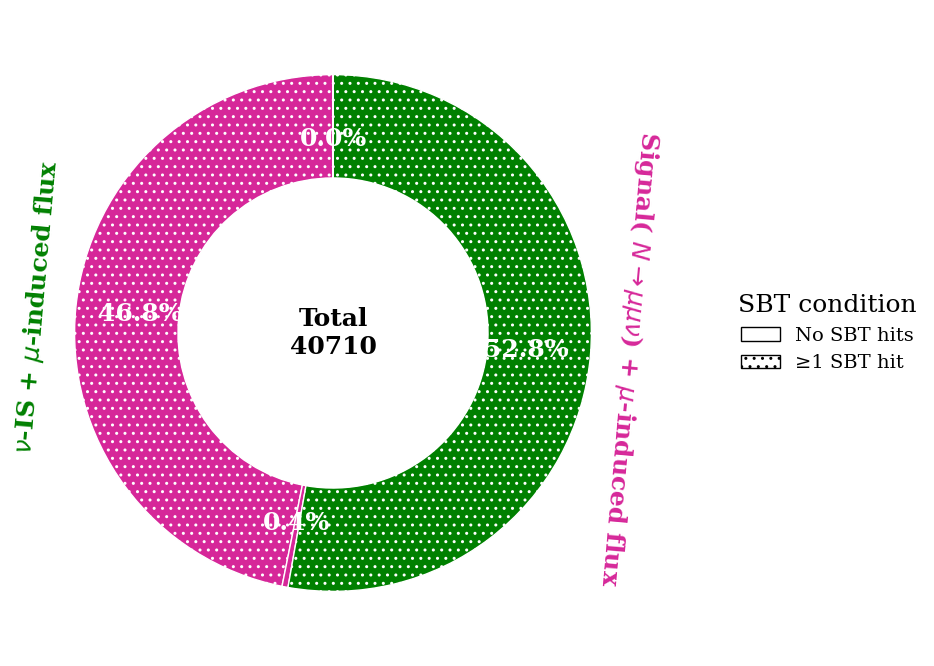

                    	| noSBT	withSBT	total
─────────────────────────────────────────────────────
Signal+MuinducedBG  	|   152	19068	19220
neuDIS+MuinducedBG  	|     7	21483	21490
─────────────────────────────────────────────────────
Combined            	|   159	40551	40710


In [15]:
print_composition_donut_gnn(X, Y,filename='GNN_DONUT.png')

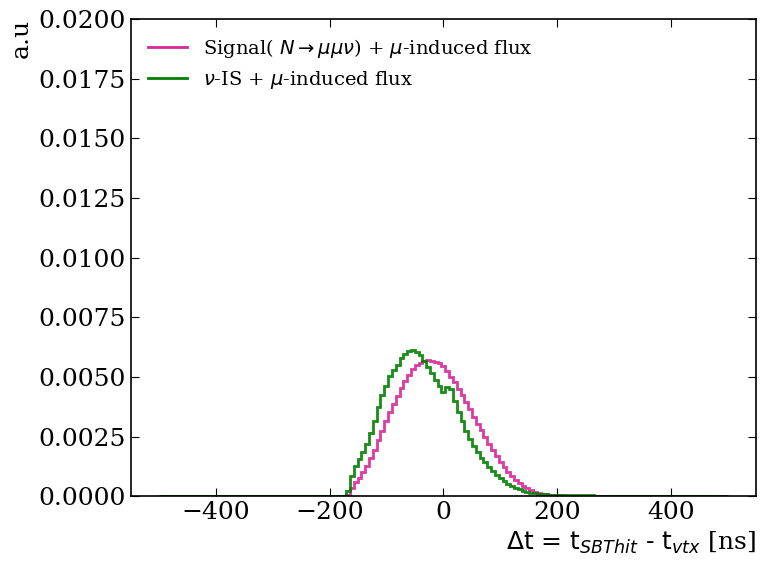

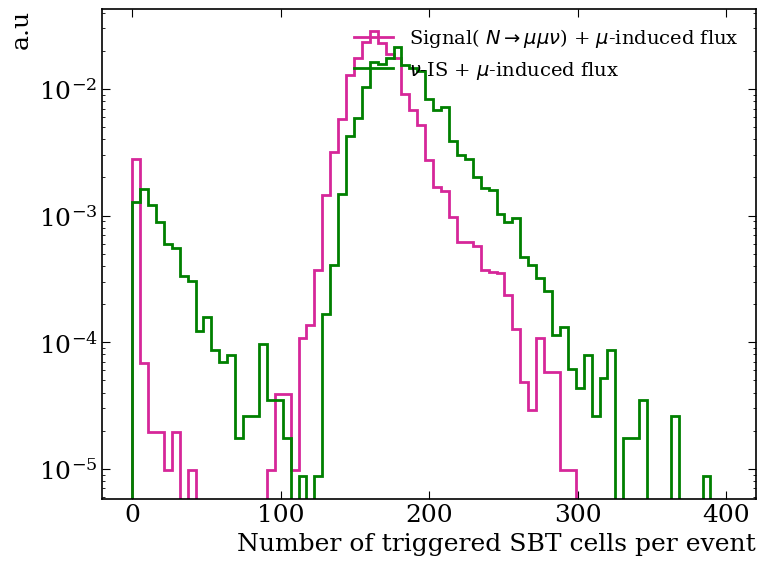

In [20]:
plot_overlayed_delta_t_histogram(X, Y,Min=-500,Max=500)
plot_overlayed_nCells_histogram(X, Y,nMax=400)

So far no threshold has been applied on the energy deposition of the cells.

In [21]:
threshold = 45  # in MeV

energies = X[:, :, 0]  
delta_t  = X[:, :, 7]

low_energy_mask = energies <= threshold * 1e-3
bad_deltat_mask = (delta_t < -150) | (delta_t > 150)

X[:, :, 0][low_energy_mask | bad_deltat_mask] = 0.0    # zero out energy below threshold
X[:, :, 7][low_energy_mask | bad_deltat_mask] = -9999  # Sentinel value for delta t since 0 is meaningful

# 4. Filter events with at least one valid energy deposition after masking
event_mask = np.any(X[:, :, 0] > 0.0, axis=1)
X_filtered = X[event_mask]
Y_filtered = Y[event_mask]
signal_info_filtered = signal_info[event_mask]

del X, Y, signal_info

print(f"Events remaining after {threshold} MeV threshold: {len(X_filtered)}")

Events remaining after 45 MeV threshold: 35755


Saved to GNNbasedveto_100326/GNN_DONUT.png


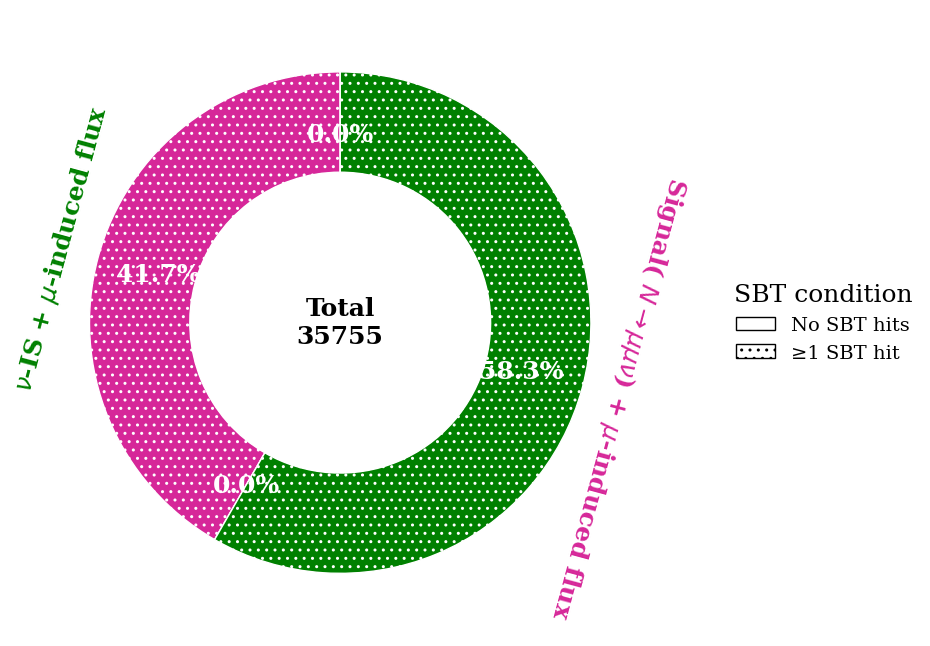

                    	| noSBT	withSBT	total
─────────────────────────────────────────────────────
Signal+MuinducedBG  	|     0	14892	14892
neuDIS+MuinducedBG  	|     0	20863	20863
─────────────────────────────────────────────────────
Combined            	|     0	35755	35755


In [22]:
print_composition_donut_gnn(X_filtered, Y_filtered,filename='GNN_DONUT.png')

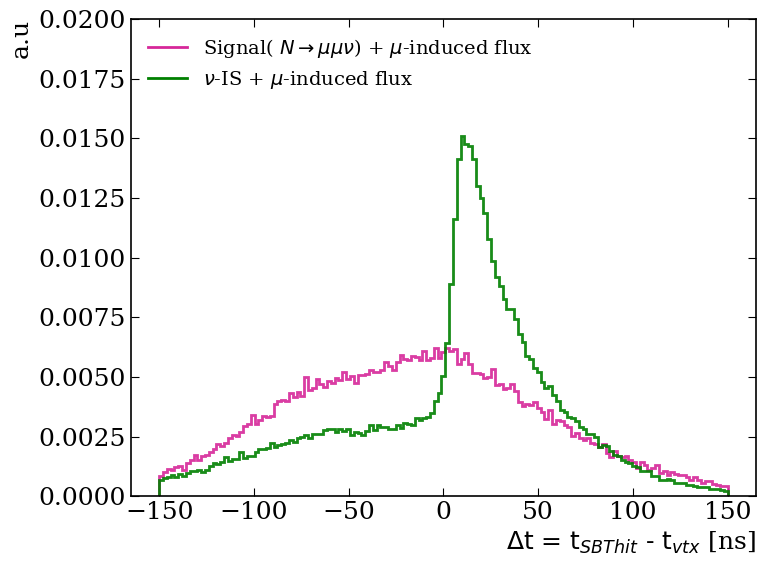

In [24]:
plot_overlayed_delta_t_histogram(X_filtered, Y_filtered,filename="thesisGNN_deltaT.pdf")

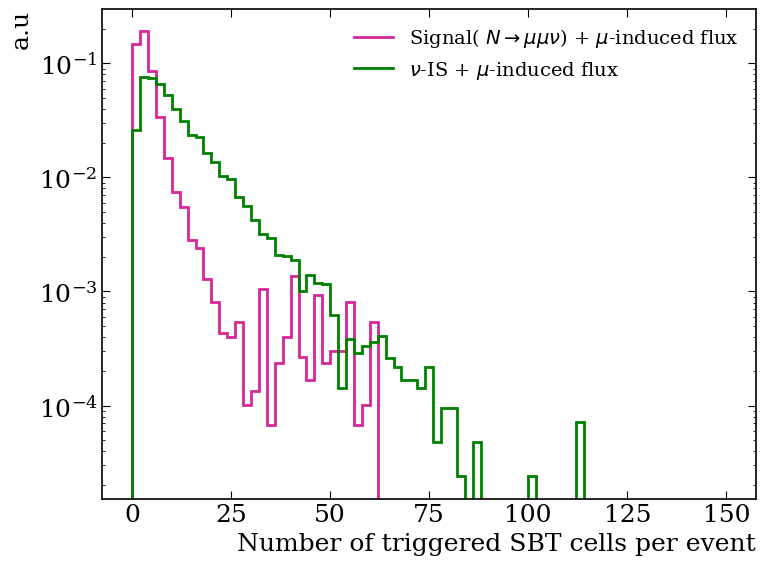

In [25]:
plot_overlayed_nCells_histogram(X_filtered, Y_filtered,filename="thesisGNN_nSBTCells.pdf")

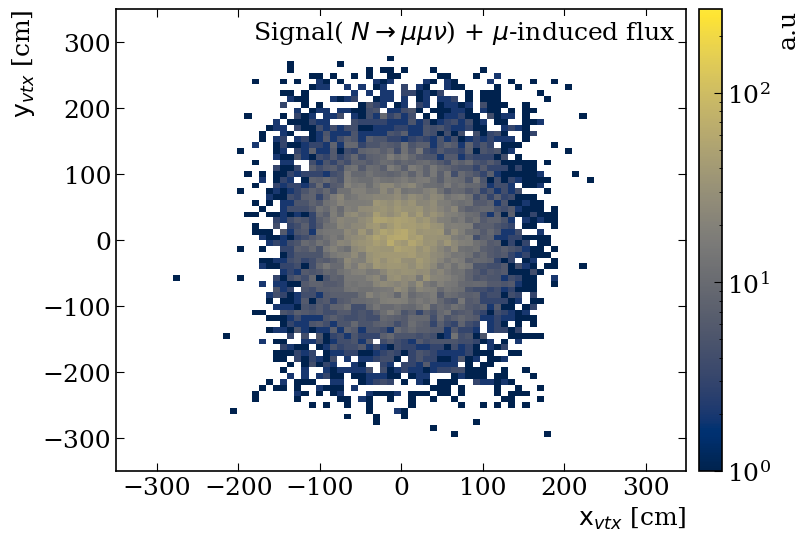

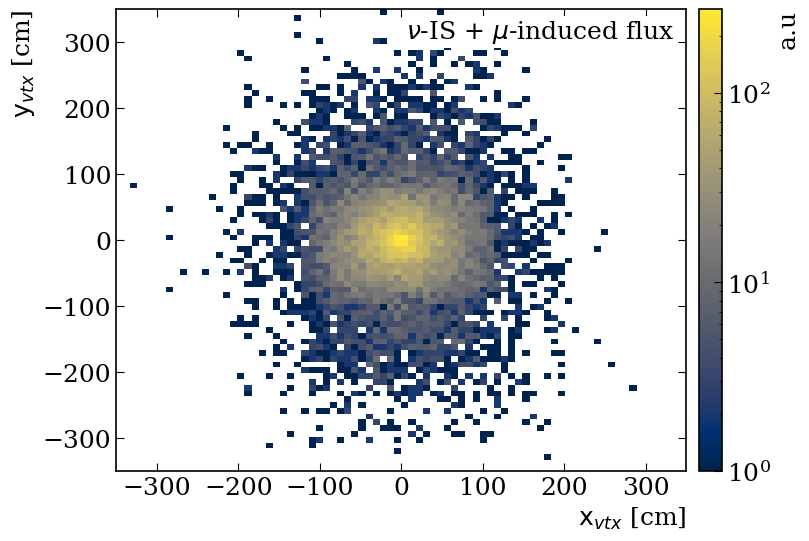

In [28]:
vtx_all = X_filtered[:, 0, 4:7].astype(float)

mask_sig = (Y_filtered == 0)
mask_dis = (Y_filtered == 1)

x_sig, y_sig, z_sig = vtx_all[mask_sig, 0], vtx_all[mask_sig, 1], vtx_all[mask_sig, 2]
x_dis, y_dis, z_dis = vtx_all[mask_dis, 0], vtx_all[mask_dis, 1], vtx_all[mask_dis, 2]

# Common binning/range
bins  = (80, 80)
xrng  = (-350, 350)
yrng  = (-350, 350)

# Compute common vmin/vmax for LogNorm (avoid zeros)
Hsig, xe, ye = np.histogram2d(x_sig, y_sig, bins=bins, range=[xrng, yrng])
Hdis, _,  _  = np.histogram2d(x_dis, y_dis, bins=bins, range=[xrng, yrng])
nonzero = np.r_[Hsig[Hsig>0], Hdis[Hdis>0]]
vmin = nonzero.min() if nonzero.size else 1.0
vmax = max(Hsig.max(), Hdis.max(), 1.0)

def plot_xy(x, y, title, cmap, outpdf):
    fig, ax = plt.subplots()
    h = ax.hist2d(x, y, bins=bins, range=[xrng, yrng],
                  norm=LogNorm(vmin=vmin, vmax=vmax), cmap=cmap)
    #ax.set_title(title)
    ax.set_xlabel(r"$\mathrm{x}_{vtx}$ [cm]", loc="right")
    ax.set_ylabel(r"$\mathrm{y}_{vtx}$ [cm]", loc="top")
    ax.text(0.98, 0.98, title,
            transform=ax.transAxes, ha="right", va="top",
            bbox=dict(facecolor="white", edgecolor="none", pad=2))
        
    ax.tick_params(top=True, right=True, direction="in")
    cb = fig.colorbar(h[3], ax=ax, pad=0.02, fraction=0.06)
    cb.set_label("a.u",loc='top')
    fig.savefig(f"{output_dir}/{outpdf}")
    plt.show()
    plt.close(fig)


plot_xy(x_sig, y_sig, class_labels[class_map[0]] , cmap="cividis",#"Signal($ N \\rightarrow \mu\mu\\nu$) + $\\mu$-induced flux"
        outpdf="thesisGNN_vtx_xy_signal.pdf")

plot_xy(x_dis, y_dis, class_labels[class_map[1]], cmap='cividis', #r"$\nu$-DIS + $\mu$-induced flux"
        outpdf="thesisGNN_vtx_xy_nuDIS.pdf")


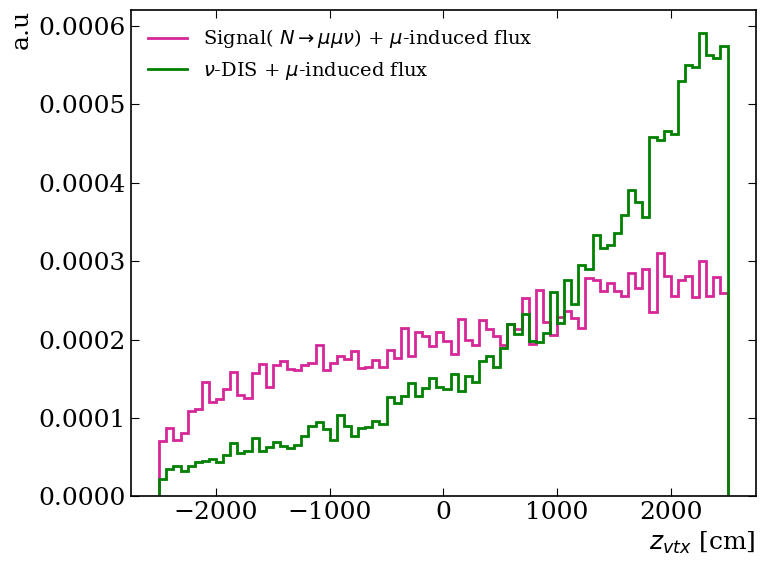

In [30]:
# Overlayed z_vtx
fig, ax = plt.subplots()
bins_z = 80

handles = [
    Line2D([0, 1], [0, 0], color=class_colors["Signal+MuinducedBG"], lw=2),   # green line
    Line2D([0, 1], [0, 0], color=class_colors["neuDIS+MuinducedBG"], lw=2),   # magenta line
]
labels = [r"Signal( $N \rightarrow \mu\mu\nu$) + $\mu$-induced flux", r"$\nu$-DIS + $\mu$-induced flux"]

leg = plt.legend(handles=handles, labels=labels, )

# draw step histograms normalized to area=1
ax.hist(z_sig, bins=bins_z, range=(-2500, 2500), histtype="step",
        color=class_colors["Signal+MuinducedBG"], linewidth=2, density=True,
        )
ax.hist(z_dis, bins=bins_z, range=(-2500, 2500), histtype="step",
        color=class_colors["neuDIS+MuinducedBG"], linewidth=2, density=True,)
        

ax.set_xlabel(r"$z_{vtx}$ [cm]", loc="right")
ax.set_ylabel("a.u", loc="top")
ax.tick_params(top=True, right=True, direction="in")
plt.tight_layout()
plt.savefig(f"{output_dir}/thesisGNN_vtx_z_overlay.pdf")
plt.show()
plt.close(fig)

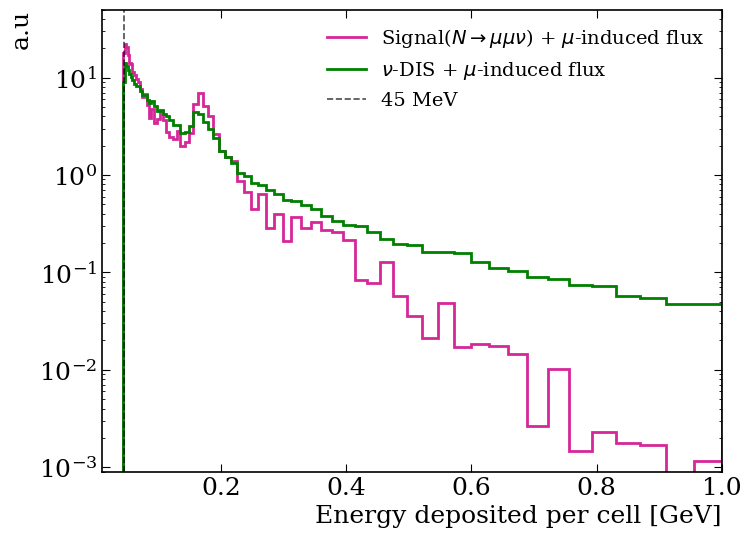

In [33]:

def plot_energy_dep_hist(X_filtered, Y_filtered, density=True,
                         outpdf="thesis_Edep_hist.pdf"):
    """
    Energy deposition overlay
    """
    E_sig = X_filtered[Y_filtered==0][:,:,0].ravel()
    E_dis = X_filtered[Y_filtered==1][:,:,0].ravel()

    lo = 0.01               # keep >0 for log
    hi = 1

    nbins = 99
    bins = np.logspace(np.log10(lo), np.log10(hi), nbins+1)

    fig, ax = plt.subplots()

    ax.hist(E_sig, bins=bins, histtype="step", linewidth=2.0, density=density,
            color=class_colors["Signal+MuinducedBG"], label=r"Signal + $\\mu$-induced flux")
    ax.hist(E_dis, bins=bins, histtype="step", linewidth=2.0, density=density,
            color=class_colors["neuDIS+MuinducedBG"], label=r"$\nu$-DIS + $\mu$-induced flux")

    ax.set_yscale("log")
    ax.set_xlim(bins[0], 1)
    ax.set_ylim(9e-4, 50)

    ax.set_ylabel("a.u", loc="top")

    ax.set_xlabel("Energy deposited per cell [GeV]", loc="right")
    ax.tick_params(top=True, right=True, direction="in")
        
    handles = [
        Line2D([0, 1], [0, 0], color=class_colors["Signal+MuinducedBG"], lw=2),   # green line
        Line2D([0, 1], [0, 0], color=class_colors["neuDIS+MuinducedBG"], lw=2),   # magenta line
        Line2D([0, 1], [0, 0], color="k", alpha=0.7, lw=1.2,ls="--"),   
    ]
    labels = [r"Signal($ N \rightarrow \mu\mu\nu$) + $\mu$-induced flux", r"$\nu$-DIS + $\mu$-induced flux","45 MeV"]

    leg = plt.legend(handles=handles, labels=labels, )

    ax.axvline(45e-3, ls="--", lw=1.2, color="k", alpha=0.7, label="45 MeV")

    plt.savefig(f"{output_dir}/{outpdf}")
    plt.show()

plot_energy_dep_hist(X_filtered, Y_filtered, density=True)


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


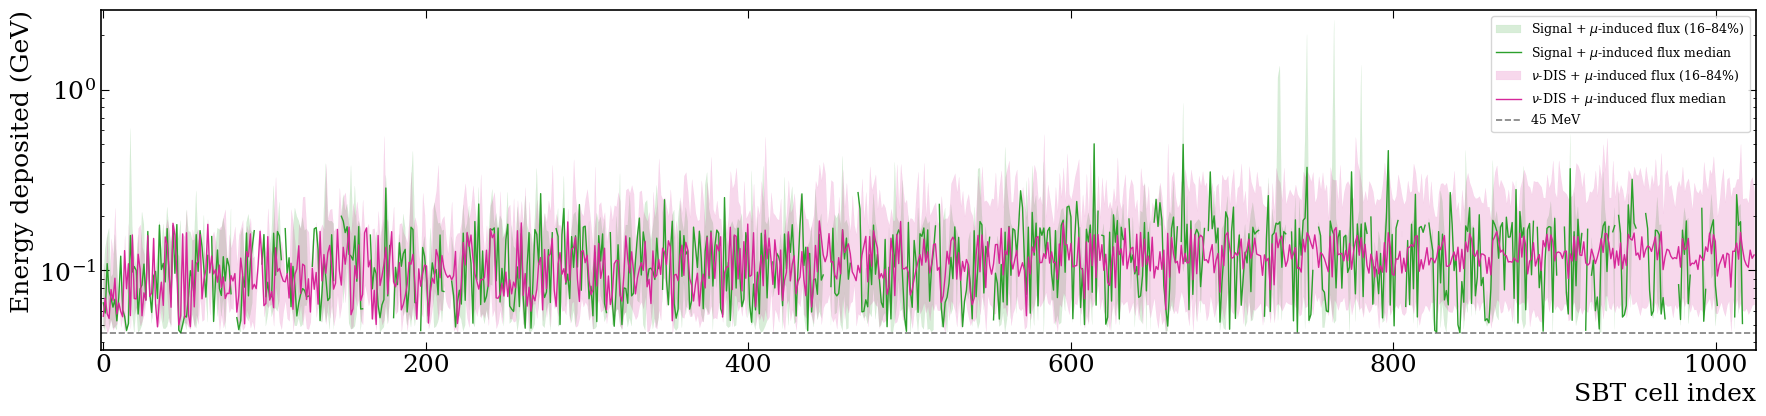

In [34]:
def plot_cell_energy_bands(X_filtered, Y_filtered, threshold_MeV=45,
                           spacing=1.2, win=11, outpdf="thesis_cell_energy_bands.pdf"):
    """
    Energy deposition trend across cells 16–84% band (shaded) + median line for both classes.
    """

    n_cells = X_filtered.shape[1]
    thr = threshold_MeV / 1000.0  # convert MeV → GeV
    base_x = np.arange(n_cells) * spacing

    colors_local = {0: "#2CA02C", 1: "#D62799"}
    labels_local = {
        0: r"Signal + $\mu$-induced flux",
        1: r"$\nu$-DIS + $\mu$-induced flux"
    }

    def percell_percentiles(E):
        """Return p16, median, p84 per cell after thresholding."""
        E = np.where(E >= thr, E, np.nan) #remove zeros for log plotting
        
        p16 = np.nanpercentile(E, 16, axis=0)
        med = np.nanmedian(E, axis=0)   # ✔ correct central statistic
        p84 = np.nanpercentile(E, 84, axis=0)

        return p16, med, p84

    def smooth(y, k=win):
        """Light smoothing for visualization only."""
        if k <= 1:
            return y

        k = int(k) | 1
        kern = np.ones(k) / k
        y_filled = np.where(np.isfinite(y), y, np.nanmedian(y))

        return np.convolve(y_filled, kern, mode="same")

    stats = {}

    for cls in (0, 1):
        E = X_filtered[Y_filtered.ravel() == cls][:, :, 0]

        p16, med, p84 = percell_percentiles(E)
        
        p16 = np.maximum(p16, thr)
        med = np.maximum(med, thr)
        p84 = np.maximum(p84, thr)

        # smoothing is applied to the curves purely for visual clarity, reducing cell-level statistical fluctuations
        #p16 = smooth(p16)
        #med = smooth(med)
        #p84 = smooth(p84)

        stats[cls] = (p16, med, p84)

    # determine y limits
    E_all = np.where(X_filtered[:, :, 0] >= thr, X_filtered[:, :, 0], np.nan)
    valid = E_all[np.isfinite(E_all)]

    ymin = min(thr, (np.nanpercentile(valid, 1) if valid.size else thr) * 0.8)
    ymax = (np.nanpercentile(valid, 99) if valid.size else 1.0) * 2.0

    fig, ax = plt.subplots(figsize=(18, 4.5))

    for cls in (0, 1):
        p16, med, p84 = stats[cls]

        ax.fill_between(base_x, p16, p84,
                        color=colors_local[cls],
                        alpha=0.18,
                        linewidth=0.1,
                        label=f"{labels_local[cls]} (16–84%)")

        ax.plot(base_x, med,
                color=colors_local[cls],
                lw=1,
                label=f"{labels_local[cls]} median")

    ax.axhline(thr, ls="--", lw=1.2, color="k", alpha=0.5, label="45 MeV")

    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(-spacing, (n_cells - 1) * spacing + spacing)

    ax.set_ylabel("Energy deposited (GeV)", loc="top")
    ax.set_xlabel("SBT cell index", loc="right")

    ax.tick_params(top=True, right=True, direction="in")

    ax.legend(frameon=True, loc="upper right", fontsize=9)

    plt.tight_layout()
    # plt.savefig(outpdf)
    plt.savefig(f"{output_dir}/{outpdf}")
    plt.show()
plot_cell_energy_bands(X_filtered, Y_filtered)

In [35]:
def add_sbt_frustum_soft(ax,
    z_start=-2500, z_end=2500,
    hx_f=74, hy_f=159, hx_b=224, hy_b=324,
    face_color='#e6f2fa', face_alpha=0.05,
    front_color='0.35', back_color='0.55', conn_color='0.55',
    lw=0.8):
    # vertices (x,y,z)
    FTL = (-hx_f,  +hy_f, z_start); FTR = (+hx_f, +hy_f, z_start)
    FBR = (+hx_f,  -hy_f, z_start); FBL = (-hx_f, -hy_f, z_start)
    BTL = (-hx_b,  +hy_b, z_end  ); BTR = (+hx_b, +hy_b, z_end  )
    BBR = (+hx_b,  -hy_b, z_end  ); BBL = (-hx_b, -hy_b, z_end  )

    faces_xyz = [
        [FTL, FTR, FBR, FBL],  # front
        [BTL, BTR, BBR, BBL],  # back
        [FTL, FTR, BTR, BTL],  # top
        [FBL, FBR, BBR, BBL],  # bottom
        [FTR, FBR, BBR, BTR],  # right
        [FTL, FBL, BBL, BTL],  # left
    ]
    
    faces = [[(x, z, y) for (x,y,z) in f] for f in faces_xyz] # remap (x,y,z)->(X,Z,Y) for plotting

    # faces: no edges here
    poly = Poly3DCollection(faces, facecolors=face_color, edgecolors='none', alpha=face_alpha)
    ax.add_collection3d(poly)

    # build edge segments and style groups
    def seg(a,b):
        return [(a[0], a[2], a[1]), (b[0], b[2], b[1])]

    front_edges = [ (FTL,FTR), (FTR,FBR), (FBR,FBL), (FBL,FTL) ]
    back_edges  = [ (BTL,BTR), (BTR,BBR), (BBR,BBL), (BBL,BTL) ]
    conn_edges  = [ (FTL,BTL), (FTR,BTR), (FBR,BBR), (FBL,BBL) ]

    lc_front = Line3DCollection([seg(a,b) for a,b in front_edges],
                                colors=back_color, linewidths=lw, linestyles='-',alpha=0.2)
    lc_back  = Line3DCollection([seg(a,b) for a,b in back_edges],
                                colors=back_color, linewidths=lw, linestyles='-', alpha=0.2)
    lc_conn  = Line3DCollection([seg(a,b) for a,b in conn_edges],
                                colors=conn_color, linewidths=lw, linestyles='-',  alpha=0.2)

    ax.add_collection3d(lc_conn)
    ax.add_collection3d(lc_back)
    ax.add_collection3d(lc_front)


3267


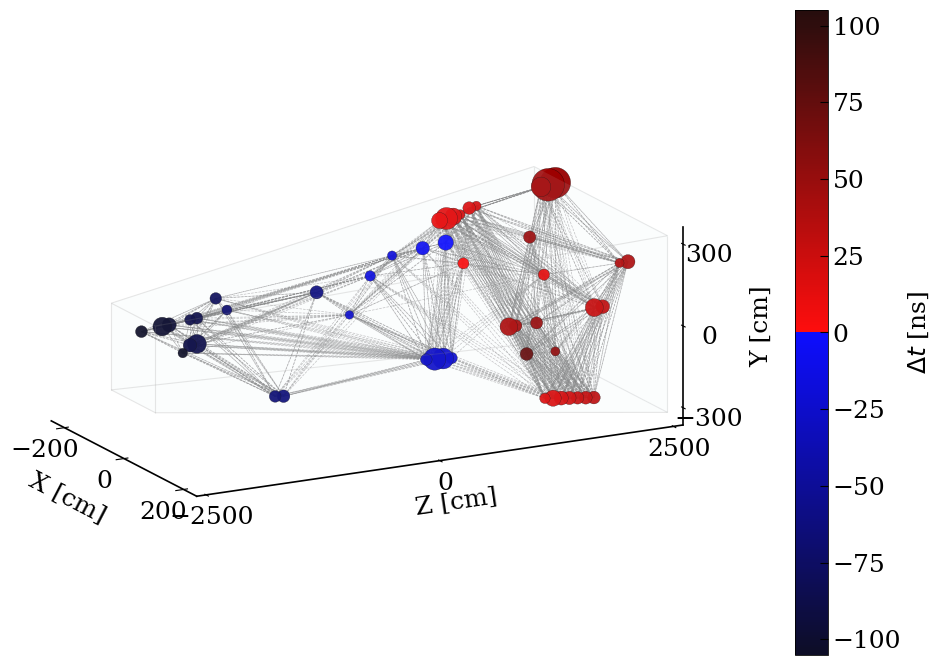

In [36]:

#hit_counts = np.count_nonzero(X_filtered[Y_filtered==1][:, :, 0] > 0, axis=1)
#good_idxs = np.where(hit_counts >= 50)[0]
#print(f"Indices of events with >=50 hits: {good_idxs}")


# 3D Graph Plot of sample event
event_idx = 3267 #35646 

if True: #for event_idx in good_idxs (SWAN CAN CRASH IF ALL PRINTED)

    my_event = X_filtered[Y_filtered==1][event_idx]  # Shape: (854, features)
    
    fig = plt.figure(figsize=(12, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_proj_type('ortho')
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.set_alpha(0.0)
    ax.grid(False)

    
    hits = my_event[:, 0]
    Xcoord = my_event[:, 1]
    Ycoord = my_event[:, 2]  
    Zcoord = my_event[:, 3]
    delta_t   = my_event[:, 7] 
    
    nonzero_mask = hits > 0

    Xcoord = Xcoord[nonzero_mask]
    Ycoord = Ycoord[nonzero_mask]
    Zcoord = Zcoord[nonzero_mask]
    hits    = hits[nonzero_mask]
    DeltaT  = delta_t[nonzero_mask]
    Edep = hits
    
    # custom sizing for Edep: exaggerated but bounded 
    # s in scatter is in points^2. Use a smooth, sublinear map so outliers don’t dominate.
    Eref   = np.quantile(0.45, 0.90)
    alpha  = 0.7                # sublinear; 1.0 is linear
    s_min, s_max = 8, 160 
    sizes = s_min + (np.clip(Edep, 0, None) / (Eref + 1e-9))**alpha * (s_max - s_min)

    # colormap for delta t
    amax  = np.quantile(np.abs(DeltaT), 0.98) if DeltaT.size else 1.0
    norm  = TwoSlopeNorm(vmin=-amax, vcenter=0.0, vmax=amax)

    sc = ax.scatter(Xcoord, Zcoord, Ycoord,
                    c=DeltaT, cmap='BlueRed3', norm=norm,
                    s=sizes, linewidths=0.2, edgecolors='k', alpha=0.95)
    cbar = plt.colorbar(sc, ax=ax, pad=0.10)
    cbar.set_label(r'$\Delta t$ [ns]')


    use_knn = True
    
    if use_knn: #build graph for this event

        nonzero_mask = hits > 0

        Xcoord = Xcoord[nonzero_mask]
        Ycoord = Ycoord[nonzero_mask]
        Zcoord = Zcoord[nonzero_mask]
        hits    = hits[nonzero_mask]

        colors_ = hits  

        positions = torch.tensor(np.stack([Xcoord, Zcoord, Ycoord], axis=1), dtype=torch.float)

        hits_t = torch.tensor(hits, dtype=torch.float)

        edge_index = knn_graph(positions, k=20)

        senders = edge_index[0].numpy()
        receivers = edge_index[1].numpy()

        for s, r in zip(senders, receivers):
            xs = [Xcoord[s], Xcoord[r]]
            zs = [Zcoord[s], Zcoord[r]]
            ys = [Ycoord[s], Ycoord[r]]
            ax.plot(xs, zs, ys, color='gray', alpha=0.5, linewidth=0.5,linestyle='--')

        add_sbt_frustum_soft(ax)
        
        ax.xaxis.set_ticks([-200, 0, 200])
        ax.yaxis.set_ticks([-2500, 0, 2500])   # detector Z on axis Y
        ax.zaxis.set_ticks([-300, 0, 300])     # detector Y on axis Z
        ax.tick_params(pad=2, length=3, width=0.6)
        
        ax.set_xlabel("\nX [cm]")        
        
        ax.set_xlim(-224-20, 224+20)
        ax.set_ylim(-2500-100, 2500+100)
        ax.set_zlim(-324-40, 324+40)
        ax.set_box_aspect((1.8, 3.2, 1.2))   # pleasant ratio for rendering

        
        ax.view_init(elev=16, azim=-28) #View angle

        for spine in cbar.ax.spines.values():
            spine.set_linewidth(0.6) #Slim colorbar
        
        
        ax.set_ylabel("\nZ [cm]")
        ax.set_zlabel("\nY [cm]")
        #ax.set_title(f"Event {event_idx}")
        plt.tight_layout()
        print(event_idx)
        plt.savefig(f"{output_dir}/GNN_3Dknnlayout_{event_idx}.pdf")
        plt.show()
        plt.close(fig)


This is the graph visualisation of a BG event.

Saved to GNNbasedveto_100326/GNN_DONUT_testdata.png


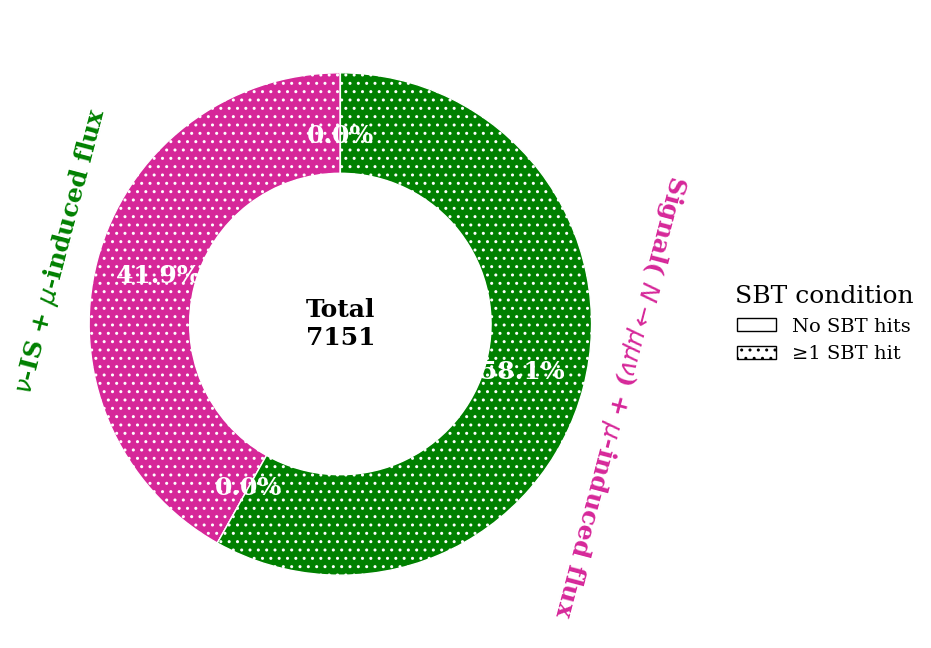

                    	| noSBT	withSBT	total
─────────────────────────────────────────────────────
Signal+MuinducedBG  	|     0	 2993	 2993
neuDIS+MuinducedBG  	|     0	 4158	 4158
─────────────────────────────────────────────────────
Combined            	|     0	 7151	 7151


In [37]:

X_temp, X_test, Y_temp, Y_test, sig_temp, sig_test = train_test_split( X_filtered, Y_filtered, signal_info_filtered, test_size=0.2, random_state=42)


print_composition_donut_gnn(X_test,Y_test,"GNN_DONUT_testdata.png")

#split temp to train and validate
X_train, X_val, Y_train, Y_val, sig_train, sig_val = train_test_split( X_temp, Y_temp, sig_temp, test_size=0.25, random_state=42)

del X_temp,Y_temp,sig_temp


In [38]:
#Building Graph Datasets

def create_graph_data(X_SBT, X_sig, Y_labels):
    """
    Convert processed arrays into a list of torch_geometric Data objects.
    """
    data_list = []
    global_idx = 0
    edge_counts=[]
    graph_sizes=[]

    for i in range(X_SBT.shape[0]):
        
        
        event = X_SBT[i]               # shape (854, n_features)
        energy_mask = event[:, 0] > 0  # keep only cells with nonzero energy
        dt_mask     = event[:, 7] != -9999  # keep only cells with a valid Δt
        # combine them
        node_mask = energy_mask & dt_mask

        
        Xcon = event[node_mask]        # now shape (N_hits, n_features)
        
        phi_column = np.expand_dims(np.arctan2(Xcon[:, 2], Xcon[:, 1]), axis=1) # Add the 'phi' column here
        Xcon = np.hstack([Xcon, phi_column])

        n_nodes = Xcon.shape[0]
        graph_sizes.append(n_nodes)


        # Node features
        Xcon_torch = torch.tensor(Xcon, dtype=torch.float)

        # Compute adjacency
        if Xcon.shape[0] < 22: # if less than threshold, fully connect them  
            A = adjacency2(Xcon.shape[0] - 1)
            edge_index = torch.tensor(A, dtype=torch.float).nonzero().t().contiguous()
        else:
            # K-NN adjacency
            k = 20
            edge_index = knn(Xcon_torch, Xcon_torch, k)
            edge_index = edge_index[:, edge_index[0] != edge_index[1]] # remove self-connections

        num_edges = edge_index.shape[1]
        edge_counts.append(num_edges)

        # Edge features: r, delta_z, delta_phi
        senders = edge_index[0].numpy()
        receivers = edge_index[1].numpy()

        
        r = np.sqrt(np.sum((Xcon[senders, 1:4] - Xcon[receivers, 1:4]) ** 2, axis=1))
        
        delta_z = Xcon[senders, 3] - Xcon[receivers, 3]
        
        phi_senders = np.arctan2(Xcon[senders, 2], Xcon[senders, 1])
        phi_receivers = np.arctan2(Xcon[receivers, 2], Xcon[receivers, 1])
        delta_phi = phi_senders - phi_receivers

        edge_features = np.vstack([r, delta_z, delta_phi]).T
        edge_features_torch = torch.tensor(edge_features, dtype=torch.float)


        global_features = np.hstack([[Xcon.shape[0]]])
        global_features_torch = torch.tensor(global_features, dtype=torch.float).unsqueeze(0)

        sig_vars_torch = torch.tensor(X_sig[i], dtype=torch.float).unsqueeze(0)


        Y_torch = torch.tensor(Y_labels[i], dtype=torch.long)


        data = Data(
            nodes=Xcon_torch,
            edge_index=edge_index,
            edges=edge_features_torch,
            graph_globals=global_features_torch,
            sig_vars=sig_vars_torch,
            y=Y_torch
        )

        data["receivers"] = data.edge_index[1]
        data["senders"] = data.edge_index[0]


        data_list.append(data)
        global_idx += 1

    plt.figure(figsize=(5, 4))
    plt.hist(edge_counts, bins=50)
    plt.xlabel("# edges per graph")
    plt.ylabel("Count")
    plt.title("Edge count distribution")
    plt.savefig("GNN_edge_count_distribution.png")
    plt.close()

    plt.figure(figsize=(5, 4))
    plt.hist(graph_sizes, bins=50)
    plt.xlabel("Number of nodes per graph")
    plt.ylabel("Count")
    plt.title("Distribution of graph sizes")
    plt.savefig("GNN_graph_size_distribution.png")
    plt.close()

    return data_list

start_time = time.time()
train_data = create_graph_data(X_train, sig_train, Y_train)
print(f"Train graph data creation took {time.time() - start_time:.2f}s")

start_time = time.time()
val_data = create_graph_data(X_val, sig_val, Y_val)
print(f"Val graph data creation took {time.time() - start_time:.2f}s")

start_time = time.time()
test_data = create_graph_data(X_test, sig_test, Y_test)
print(f"Test graph data creation took {time.time() - start_time:.2f}s")


Train graph data creation took 9.62s
Val graph data creation took 4.41s
Test graph data creation took 3.68s


In [39]:

# Build loaders

train_loader    = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader      = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader     = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print("Number of train samples:", len(train_data))
print("Number of val samples:", len(val_data))



Number of train samples: 21453
Number of val samples: 7151


----------------------------------------------------------------------------
## Training the GNN

In [40]:

#Initialize the GNN Model

STEP_SIZE = 2
MLP_OUTPUT_SIZE = 8
HIDDEN_CHANNELS = 64
NUM_LAYERS = 4

model = EncodeProcessDecode(
    mlp_output_size=MLP_OUTPUT_SIZE,
    global_op=1,        # 1 output 
    num_blocks=4        # e.g. 4 message-passing steps
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


EncodeProcessDecode(
  (_encoder): MLPGraphIndependent(
    (_network): GraphIndependent(
      (_edge_model): WrappedModelFnModule(
        (_model): MLP(-1, 128, 128, 128, 8)
      )
      (_node_model): WrappedModelFnModule(
        (_model): MLP(-1, 128, 128, 128, 8)
      )
      (_global_model): WrappedModelFnModule(
        (_model): MLP(-1, 128, 128, 128, 8)
      )
    )
  )
  (_core): MLPGraphNetwork(
    (_network): GraphNetwork(
      (_edge_block): EdgeBlock(
        (_edge_model): MLP(-1, 128, 128, 128, 8)
      )
      (_node_block): NodeBlock(
        (_node_model): MLP(-1, 128, 128, 128, 8)
        (_sent_edges_aggregator): EdgesToNodesAggregator()
      )
      (_global_block): GlobalBlock(
        (_global_model): MLP(-1, 128, 128, 128, 8)
        (_edges_aggregator): EdgesToGlobalsAggregator()
        (_nodes_aggregator): NodesToGlobalsAggregator()
      )
    )
  )
  (_blocks): ModuleList(
    (0-3): 4 x MLPGraphNetwork(
      (_network): GraphNetwork(
        (_ed

In [41]:

#Training the Model

optimizer_GCN = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.BCEWithLogitsLoss() 

losses = []
vallosses = []
accs,  valaccs    = [], []  
nepochs=25

for epoch in range(1,nepochs+1):
    start_epoch_time = time.time()
    if epoch == 20:
        optimizer_GCN = torch.optim.Adam(model.parameters(), lr=0.0001)

    model.train()
    epoch_loss = 0
    correct_train = 0            
    total_train   = 0            
    batch_start = time.time()
    for i,b in enumerate(train_loader):

        b = b.to(device)
        b['receivers'] = b.edge_index[1]
        b['senders'] = b.edge_index[0]
        b['edgepos'] = b.batch[b['senders']]

        optimizer_GCN.zero_grad()

        out = model(b)
        logits = out['graph_globals']  # [batch_size, num_classes]
        loss = criterion(logits, b.y.float().unsqueeze(1))  # b.y: [batch_size] with class indices

        loss.backward()
        optimizer_GCN.step()

        epoch_loss += loss.item() / len(train_loader)
        
        # ---------- accuracy ----------
        with torch.no_grad():                       # no grad needed
            preds = (torch.sigmoid(logits) > 0.5)   
            correct_train += (preds.view(-1) == b.y).sum().item()
            total_train   += b.y.size(0)

        
        #print(f"Train batch took {time.time() - batch_start:.2f}s")
        #batch_start = time.time()


    model.eval()
    val_epoch_loss = 0
    val_prob_list = []
    val_true_list = []
    with torch.no_grad():
        for b in val_loader:
            b = b.to(device)
            b['receivers'] = b.edge_index[1]
            b['senders'] = b.edge_index[0]
            b['edgepos'] = b.batch[b['senders']]

            out = model(b)
            logits = out['graph_globals']
            val_loss = criterion(logits, b.y.float().unsqueeze(1))
            val_epoch_loss += val_loss.item() / len(val_loader)

            # --- collect ground truth and sigmoid scores ---
            probs = torch.sigmoid(logits).view(-1)        # shape [batch,]
            val_prob_list.append(probs.cpu())
            val_true_list.append(b.y.cpu().float())      # shape [batch,]

    print(f"Epoch {epoch:02d} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_epoch_loss:.4f} | Time: {time.time() - start_epoch_time:.2f}s")
    losses.append(epoch_loss)
    vallosses.append(val_epoch_loss)



Epoch 01 | Train Loss: 0.3677 | Val Loss: 0.3110 | Time: 48.55s
Epoch 02 | Train Loss: 0.3061 | Val Loss: 0.2450 | Time: 37.28s
Epoch 03 | Train Loss: 0.2599 | Val Loss: 0.2346 | Time: 36.95s
Epoch 04 | Train Loss: 0.2453 | Val Loss: 0.2384 | Time: 36.72s
Epoch 05 | Train Loss: 0.2327 | Val Loss: 0.2273 | Time: 37.16s
Epoch 06 | Train Loss: 0.2219 | Val Loss: 0.2118 | Time: 36.94s
Epoch 07 | Train Loss: 0.2165 | Val Loss: 0.2074 | Time: 36.84s
Epoch 08 | Train Loss: 0.2197 | Val Loss: 0.2288 | Time: 36.72s
Epoch 09 | Train Loss: 0.2133 | Val Loss: 0.2023 | Time: 38.60s
Epoch 10 | Train Loss: 0.2056 | Val Loss: 0.1917 | Time: 37.20s
Epoch 11 | Train Loss: 0.2003 | Val Loss: 0.2016 | Time: 37.12s
Epoch 12 | Train Loss: 0.1982 | Val Loss: 0.2705 | Time: 37.53s
Epoch 13 | Train Loss: 0.2047 | Val Loss: 0.1765 | Time: 36.97s
Epoch 14 | Train Loss: 0.1920 | Val Loss: 0.1910 | Time: 37.14s
Epoch 15 | Train Loss: 0.1885 | Val Loss: 0.1868 | Time: 36.55s
Epoch 16 | Train Loss: 0.1870 | Val Loss

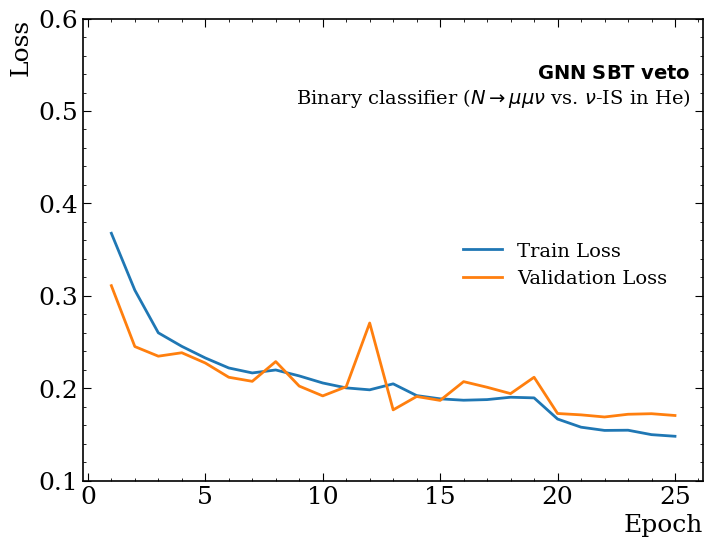

In [42]:

epochs_range = range(1, nepochs + 1)
fig, ax = plt.subplots()
ax.plot(epochs_range, losses, label="Train Loss")
ax.plot(epochs_range, vallosses, label="Validation Loss")
ax.set_xlabel("Epoch",loc="right")
ax.set_ylim(0.1,0.6)
ax.set_ylabel("Loss",loc="top")
ax.legend(loc=(0.6,0.4))
ax.tick_params(top=True, right=True, direction="in")
ax.minorticks_on()

footer = (
    r"$\bf{GNN\ SBT\ veto}$" "\n"
    f"Binary classifier ($ N\\rightarrow\\mu\\mu\\nu $ vs. $ \\nu $-IS in He)\n" 
    #f"Binary classifier\n( {class_labels[class_map[0]]} \n vs. {class_labels[class_map[1]]} ) \n" 
)

ax.text(
    0.98, 0.9, footer,
    transform=ax.transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.25", fc="none", ec="none", alpha=1),size=14,
    zorder=4, clip_on=False
)
fig.savefig(f"{output_dir}/thesisGNN_Losscurve.pdf")
plt.show()
plt.close(fig)

In [43]:
# Compute ROC 

val_probs = torch.cat(val_prob_list).numpy()      
val_true  = torch.cat(val_true_list).numpy()   

fpr, tpr, thresholds = roc_curve(val_true, val_probs, pos_label=1) #    Here pos_label=1 means we treat class “1” (BG) as the “positive” class for FPR
roc_auc = auc(fpr, tpr)


finite = np.isfinite(thresholds)
fpr_f, tpr_f, thr_f = fpr[finite], tpr[finite], thresholds[finite]

# compute Youden's J at each point
J = tpr_f - fpr_f

# pick the index that maximizes J
best_idx = np.argmax(J)
best_thresh = thr_f[best_idx]
best_fpr    = fpr_f[best_idx]
best_tpr    = tpr_f[best_idx]

print(f"→ Threshold @ max(J) = {best_thresh:.3f} (FPR={best_fpr:.4f}, TPR={best_tpr:.4f})")


→ Threshold @ max(J) = 0.555 (FPR=0.0548, TPR=0.9231)


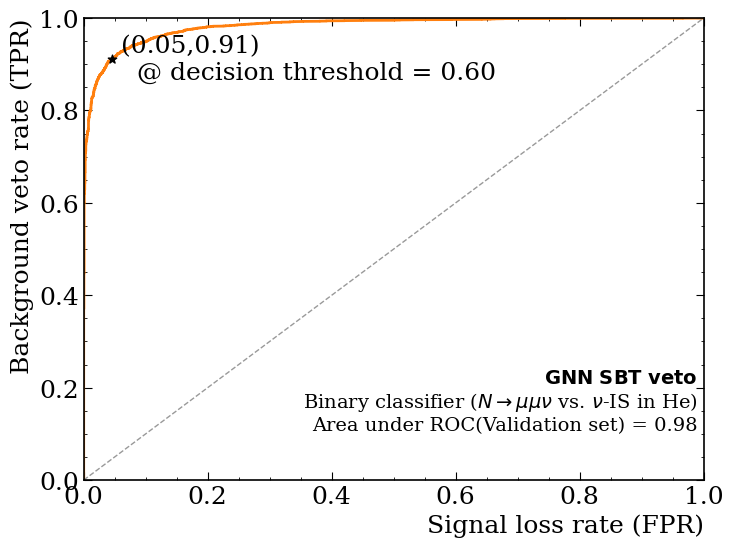

In [44]:

cut = 0.60 #decison threshold chosen

ix_cut = np.argmin(np.abs(thresholds - cut))
tpr_cut, fpr_cut = tpr[ix_cut], fpr[ix_cut]


fig, ax = plt.subplots()

ax.plot(fpr, tpr, label=f"Area under ROC = {roc_auc:.2f}",color="tab:orange")

ax.plot([0, 1], [0, 1], ls="--", lw=1.0, color="gray", alpha=0.8)

ax.scatter([fpr_cut], [tpr_cut], s=40, color="k",marker='*', zorder=5)

ax.annotate(f"({fpr_cut:.2f},{tpr_cut:.2f})\n  @ decision threshold = 0.60",
            xy=(fpr_cut, tpr_cut), xytext=(6, 0),
            textcoords="offset points", va="center")

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Signal loss rate (FPR)", loc="right")
ax.set_ylabel("Background veto rate (TPR)",  loc="top")
ax.tick_params(top=True, right=True, direction="in")
ax.minorticks_on()

footer = (
    r"$\bf{GNN\ SBT\ veto}$" "\n"
    f"Binary classifier ($ N\\rightarrow\\mu\\mu\\nu $ vs. $ \\nu $-IS in He)\n" 
    #f"Binary classifier\n( {class_labels[class_map[0]]} \n vs. {class_labels[class_map[1]]} ) \n" 
    f"Area under ROC(Validation set) = {roc_auc:.2f}"
)

ax.text(
    0.99, 0.1, footer,
    transform=ax.transAxes,
    ha="right", va="bottom",
    bbox=dict(boxstyle="round,pad=0.25", fc="none", ec="none", alpha=1),size=14,
    zorder=10, clip_on=False
)

fig.savefig(f"{output_dir}/thesisGNN_ROC_validation.pdf")   # vector for thesis
plt.show()
plt.close(fig)


In [45]:

model_path = f"{output_dir}/GNNbasedveto_{threshold}MeV_{nepochs}epochs.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")


Model saved to GNNbasedveto_100326/GNNbasedveto_45MeV_25epochs.pth


In [46]:

# Evaluate Model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
state_dict = torch.load(model_path, map_location=device) #"GNN_SBTveto_BINARY_45MeV_25epochs_wdeltaT_FINAL.pth", map_location=device)

model.load_state_dict(state_dict, strict=True) 

model.eval()
y_true = []
y_pred = []
sig_store = []           # will hold one row per graph
probs_store = []
nHits_store = []                  

with torch.no_grad():

    for b in test_loader:
        b = b.to(device)

        b['receivers'] = b.edge_index[1]
        b['senders'] = b.edge_index[0]
        b['edgepos'] = b.batch[b['senders']]

        out = model(b)
        logits = out["graph_globals"]  # shape: [1, num_classes]

        
        probs     = torch.sigmoid(logits)
        predicted = (probs > 0.6).long().view(-1)


        y_true.extend(b.y.cpu().tolist())
        y_pred.extend(predicted.cpu().tolist())

        probs_store.append(probs.cpu().numpy())
        sig_store.append(b.sig_vars.squeeze(1).cpu().numpy())
        
        nHits_batch = (b.ptr[1:] - b.ptr[:-1]).cpu().numpy()   
        nHits_store.append(nHits_batch)                        




In [47]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)
sig_all = np.concatenate(sig_store, axis=0)   # shape [N_events, n_sig_features]
probs_all = np.concatenate(probs_store, axis=0)    # shape [N_events]
nHits_all = np.concatenate(nHits_store)             # (N,)
sig_all   = np.concatenate([sig_all, nHits_all[:,None]], axis=1)

assert sig_all.shape[0] == len(y_true) == len(probs_all)

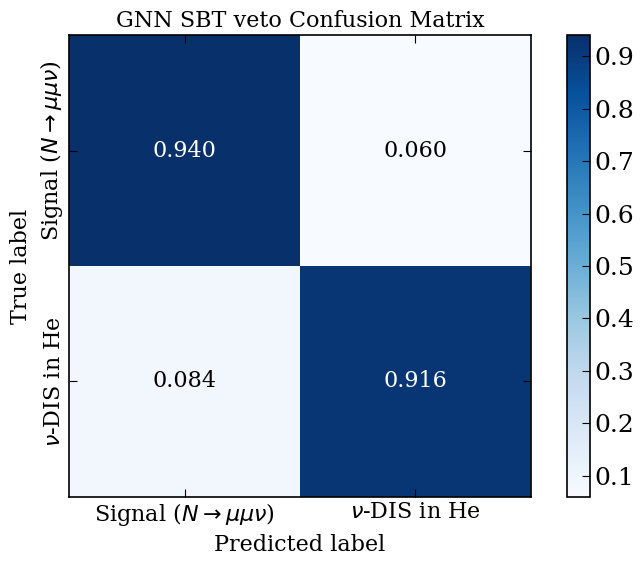

In [48]:
# Confusion Matrix
#class_names = [class_labels[class_map[0]],class_labels[class_map[1]]]#
class_names = [r"Signal ($N \rightarrow \mu\mu\nu$)", r"$\nu$-IS in He"]
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm / cm.sum(axis=1, keepdims=True) #* 100

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_percent,cmap="Blues") #norm=LogNorm(vmin=1, vmax=cm.max())

# Axis labels and title
ax.set_title("GNN SBT veto Confusion Matrix",fontsize=16)
ax.set_xlabel("Predicted label",fontsize=16)
ax.set_ylabel("True label",fontsize=16)


ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=0,fontsize=16)
ax.set_yticklabels(class_names,rotation=90,va="center",fontsize=16)


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            f"{cm_percent[i, j]:.3f}",#f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)",
            ha="center", va="center",
            color="white" if cm_percent[i, j]*100 > 50 else "black",
            fontsize=16
        )

cbar = fig.colorbar(im, ax=ax)
#cbar.set_label("Count",fontsize=16)

plt.tight_layout()
plt.savefig("GNN_CM_fraction.pdf")
plt.show()


In [49]:
accuracy = np.sum(y_true == y_pred) / len(y_true)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9259


ROC AUC: 0.9817


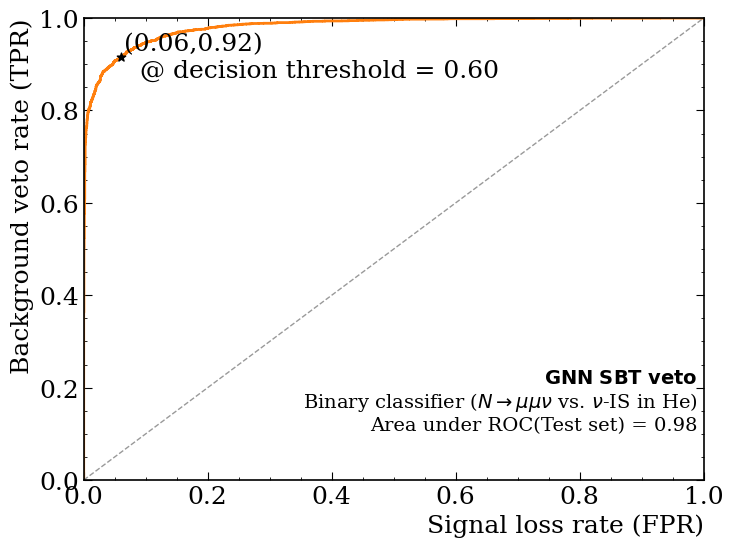

In [50]:
# ROC Curve for test

fpr, tpr, thresholds = roc_curve(y_true, probs_all)   # positive class must be 1
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

cut = 0.60
ix_cut = np.argmin(np.abs(thresholds - cut))
tpr_cut, fpr_cut = tpr[ix_cut], fpr[ix_cut]


fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f"Area under ROC = {roc_auc:.2f}",color="tab:orange")
ax.plot([0, 1], [0, 1], ls="--", lw=1.0, color="gray", alpha=0.8)
ax.scatter([fpr_cut], [tpr_cut], s=40, color="k",marker='*', zorder=5)
ax.annotate(f"({fpr_cut:.2f},{tpr_cut:.2f})\n  @ decision threshold = 0.60",
            xy=(fpr_cut, tpr_cut), xytext=(2, 0),
            textcoords="offset points", va="center")

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Signal loss rate (FPR)", loc="right")
ax.set_ylabel("Background veto rate (TPR)",  loc="top")
ax.tick_params(top=True, right=True, direction="in")
ax.minorticks_on()

footer = (
    r"$\bf{GNN\ SBT\ veto}$" "\n"
    f"Binary classifier ($ N\\rightarrow\\mu\\mu\\nu $ vs. $ \\nu $-IS in He)\n" 
    f"Area under ROC(Test set) = {roc_auc:.2f}"
)

ax.text(
    0.99, 0.1, footer,
    transform=ax.transAxes,
    ha="right", va="bottom",
    bbox=dict(boxstyle="round,pad=0.25", fc="none", ec="none", alpha=1),size=14,
    zorder=4, clip_on=False
)

fig.savefig(f"{output_dir}/thesisGNN_ROC_test.pdf")   # vector for thesis
plt.show()
plt.close(fig)


Diagnosis wth Signal info

In [51]:
idx_sig   = np.where((y_true == 0) & (y_pred == 0))[0]   # true-positives  ( SIGNAL tagged as SIGNAL)
idx_bad_s = np.where((y_true == 0) & (y_pred == 1))[0]   # false-negatives ( SIGNAL tagged as BG)
idx_bg    = np.where((y_true == 1) & (y_pred == 1))[0]   # true-negatives  ( BG tagged as BG)
idx_bad_b = np.where((y_true == 1) & (y_pred == 0))[0]   # false-positives ( BG tagged as SIGNAL)

sig_info_tp = sig_all[idx_sig]
sig_info_fn = sig_all[idx_bad_s]
sig_info_tn = sig_all[idx_bg]
sig_info_fp = sig_all[idx_bad_b]


In [52]:

cols = {
    0 : '$x_{vtx}$ [cm]',
    1 : '$y_{vtx}$ [cm]',
    2 : '$z_{vtx}$ [cm]',
    3 : 'No. of reconstructed candidates',
    4 : 'inv. mass [GeV]',
    5 : 'DOCA [cm]',
    6 : 'Impact parameter [cm]',
    7 : 'd1_chi2',
    8 : 'd2_chi2',
    9 : 'd1_ndf',
    10: 'd2_ndf',
    11: 'd1_mom [GeV]',
    12: 'd2_mom [GeV]',
    13: 'UBT_hits',
    14: 'eventweight',
    15: 'No. of SBT Hits ($E_{\\mathrm{dep.}}$>45MeV)'
}

def prob_vs_feature(idx_feat,
                    *,
                    thresh=None,
                    flip_score=False,
                    ms=25,
                    setlog=False):
    
    # Flatten globals
    x_raw = np.asarray(probs_all, dtype=float).ravel()
    y_t   = np.asarray(y_true  , dtype=int  ).ravel()
    sig_matrix = np.asarray(sig_all, dtype=float)
    if sig_matrix.ndim != 2:
        raise RuntimeError("sig_all must be (N, nFeat)")
    y_vals = sig_matrix[:, idx_feat].ravel()

    # Build common bins
    x_edges = np.linspace(0, 1, 11)
    
    if setlog:
        y_min = max(y_vals[y_vals > 0].min(), 1e-3) # >0 for log; guard 0
        y_max = y_vals.max()*1.2
        y_edges = np.logspace(np.log10(y_min), np.log10(y_max), 51)
    else:
        y_edges = np.linspace(y_vals.min(), y_vals.max()*1.2, 51)
        

    common_bins = [x_edges, y_edges]

    # Score + threshold
    if thresh is None:
        thresh = best_thresh
    score = 1. - x_raw if flip_score else x_raw
    cut   = 1. - thresh if flip_score else thresh
    xlab  = 'Network score (signal)' if flip_score else 'Network score (background)'

    # Reclassify
    pred_bg = score > cut
    TP = (y_t == 0) & (~pred_bg)
    TN = (y_t == 1) & ( pred_bg)
    FP = (y_t == 1) & (~pred_bg)
    FN = (y_t == 0) & ( pred_bg)


    feat_name = cols.get(idx_feat, f'feature[{idx_feat}]')

    # Plot
    fig, ax = plt.subplots()#figsize=(7,5))
    divider = make_axes_locatable(ax)

    # Signal density 
    hsig = ax.hist2d(
        score[TP], y_vals[TP],
        bins=common_bins, cmap='cool_r', norm=LogNorm(), alpha=0.7
    )
    im_sig = hsig[3]
    cax1 = divider.append_axes("right", size="3%", pad=0.2)
    cb1  = fig.colorbar(im_sig, cax=cax1)
    cb1.set_label("True Signal (SIG) density", labelpad=6)
    cb1.ax.tick_params(labelsize='small')            

    # Background density
    hbg = ax.hist2d(
        score[TN], y_vals[TN],
        bins=common_bins, cmap='summer', norm=LogNorm(), alpha=0.7
    )
    im_bg = hbg[3]
    cax2 = divider.append_axes("right", size="3%")#, pad=0.6)
    cb2  = fig.colorbar(im_bg, cax=cax2)
    cb2.set_label("True background (BG) density", labelpad=6)
    cb2.ax.tick_params(labelsize='small')
    
    
    # — Mis‐ID scatter
    ax.scatter(score[FP], y_vals[FP],
               marker='x', c='green', s=ms, label='BG → SIG', zorder=5)
    ax.scatter(score[FN], y_vals[FN],
               marker='o', facecolors='none', edgecolors='magenta',
               s=ms, label='SIG → BG', zorder=5)
    
    # — Cut line
    ax.axvline(cut, ls='--', color='grey', lw=3,
               label=f'decision threshold = {thresh:.1f}')

    
    ax.set_xlim(-0.05, 1.05)
    ax.set_xlabel(f'{xlab}')
    ax.set_ylabel(feat_name)
    #ax.set_title(f'{feat_name}  vs. network score')
    
    if setlog:
        ax.set_yscale('log')


    legend_items = [
        Line2D([], [], marker='x', color='green', lw=0, ms=8, label='BG → SIG'),
        Line2D([], [], marker='o', mec='magenta', mfc='none', lw=0, ms=8,
               label='SIG → BG'),
        Line2D([], [], color='grey', ls='--', lw=3,
               label=f'decision threshold')
    ]
    ax.legend(
    handles=legend_items,
    loc='lower left',
    bbox_to_anchor=(0.0, 1.02),  
    borderaxespad=0.0,
    ncol=len(legend_items),      
    framealpha=0.9
    )

    plt.savefig(f"{output_dir}/thesisGNN{feat_name}_score.pdf")
    plt.show()
    plt.close()
    
    return fig, ax


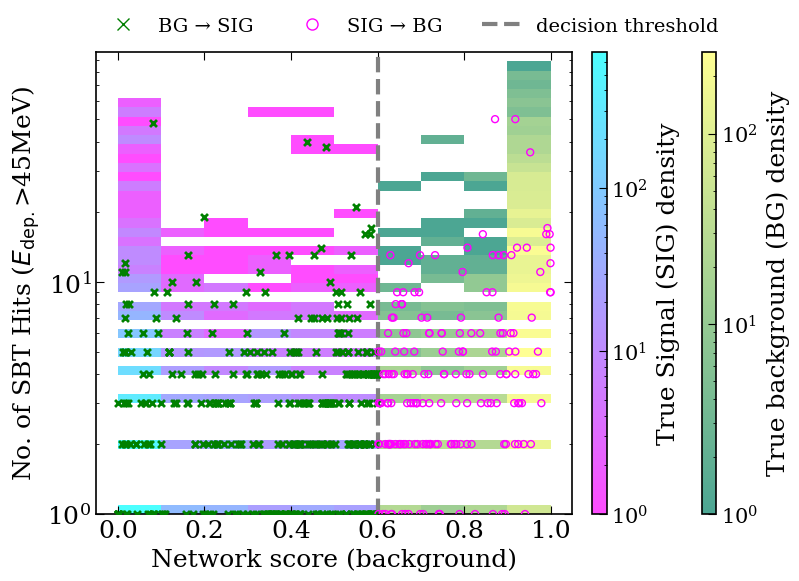

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='No. of SBT Hits ($E_{\\mathrm{dep.}}$>45MeV)'>)

In [53]:
prob_vs_feature(15,thresh=0.6,setlog=True)

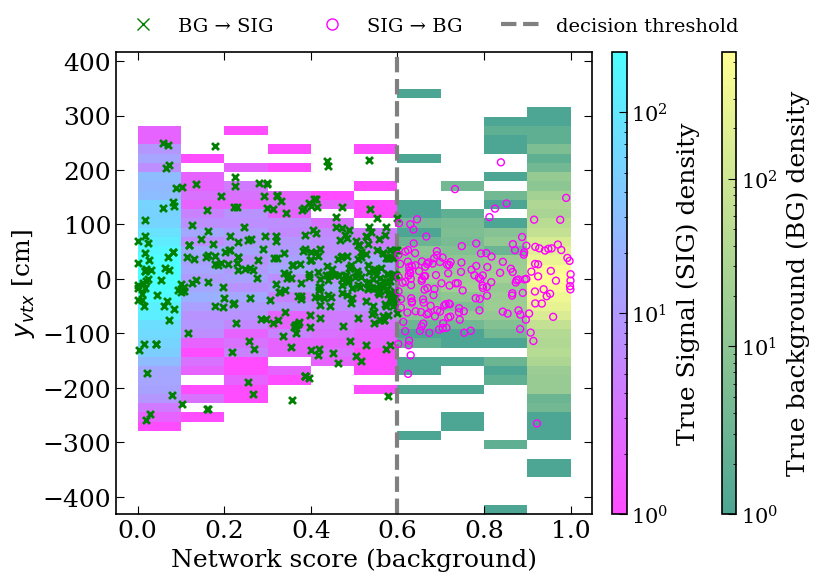

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='$y_{vtx}$ [cm]'>)

In [54]:
prob_vs_feature(1,thresh=0.6)

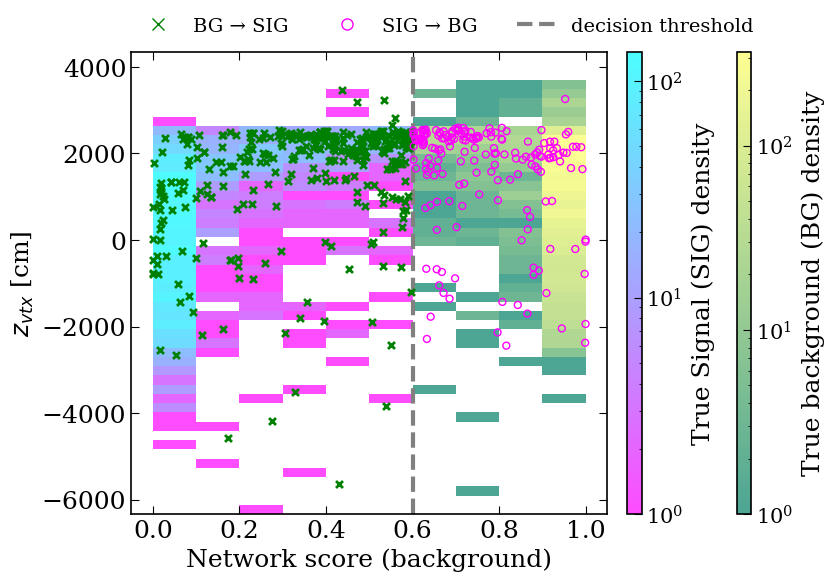

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='$z_{vtx}$ [cm]'>)

In [55]:
prob_vs_feature(2,thresh=0.6)

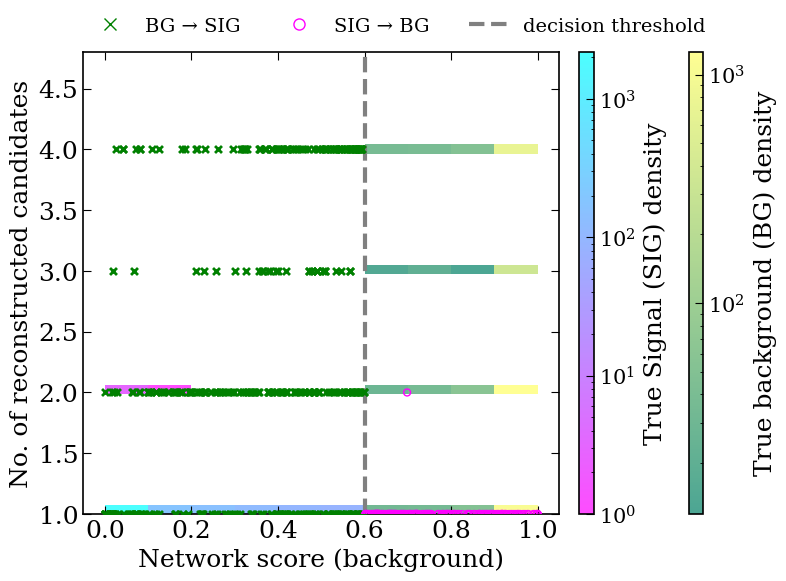

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='No. of reconstructed candidates'>)

In [56]:
prob_vs_feature(3,thresh=0.6)         

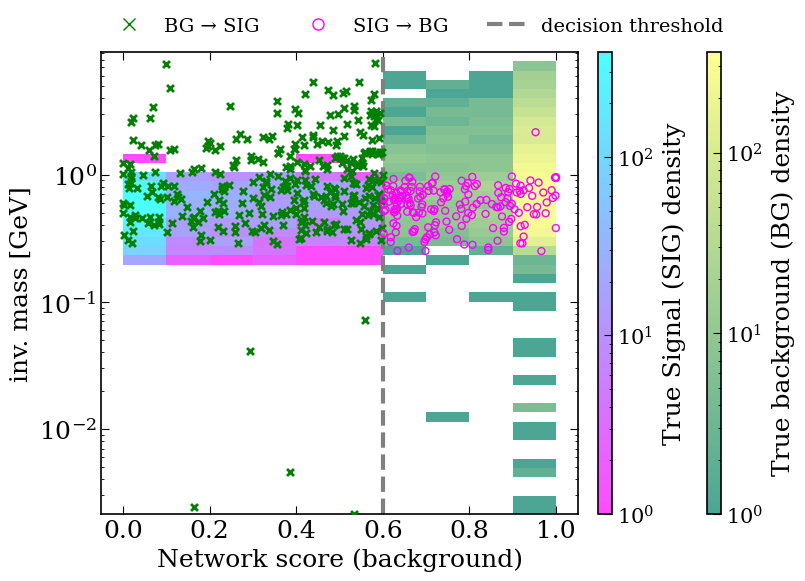

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='inv. mass [GeV]'>)

In [57]:
prob_vs_feature(4,thresh=0.6,setlog=True)

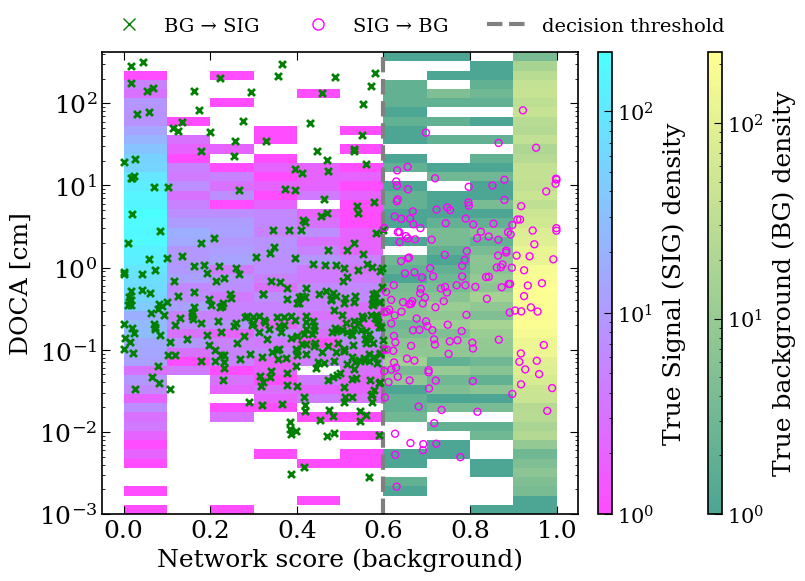

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='DOCA [cm]'>)

In [58]:
prob_vs_feature(5,thresh=0.6,setlog=True)       

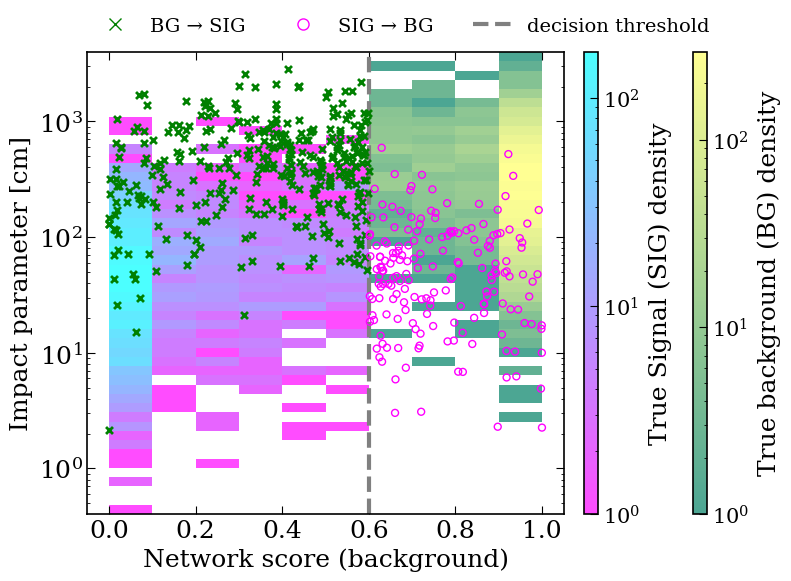

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='Impact parameter [cm]'>)

In [59]:
prob_vs_feature(6,thresh=0.6,setlog=True)

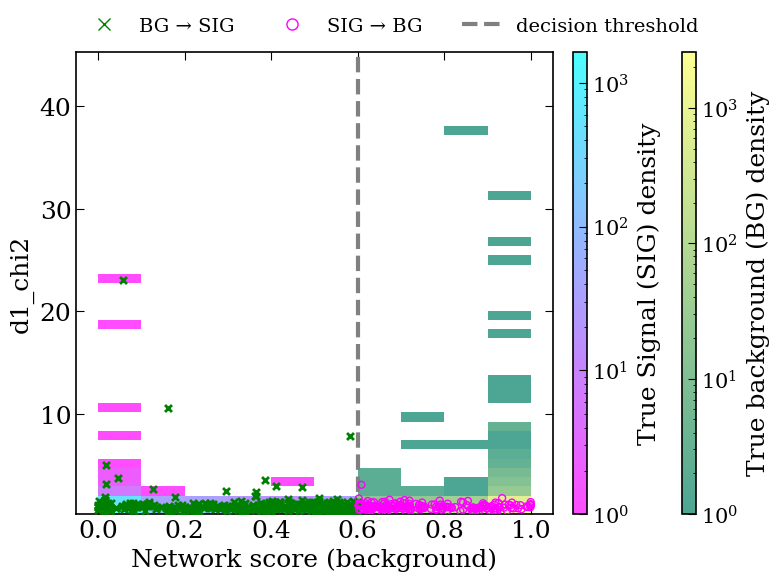

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='d1_chi2'>)

In [60]:
prob_vs_feature(7,thresh=0.6)         

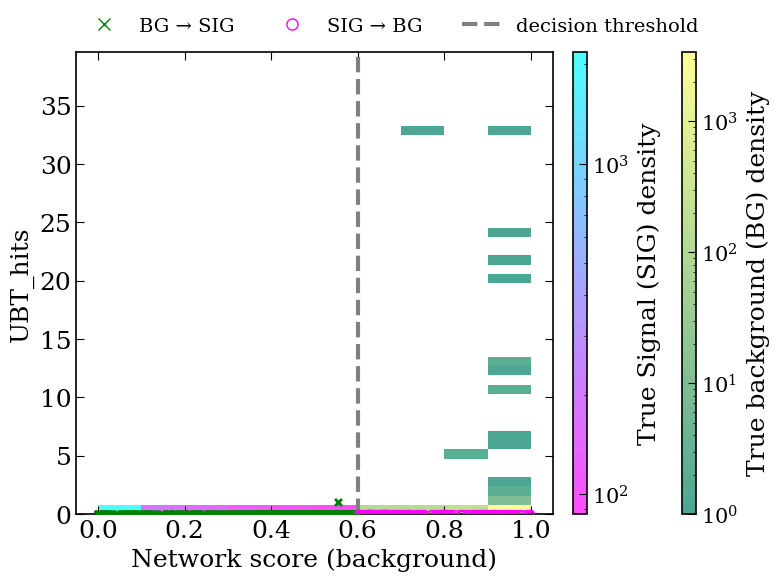

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='UBT_hits'>)

In [61]:
prob_vs_feature(13,thresh=0.6)

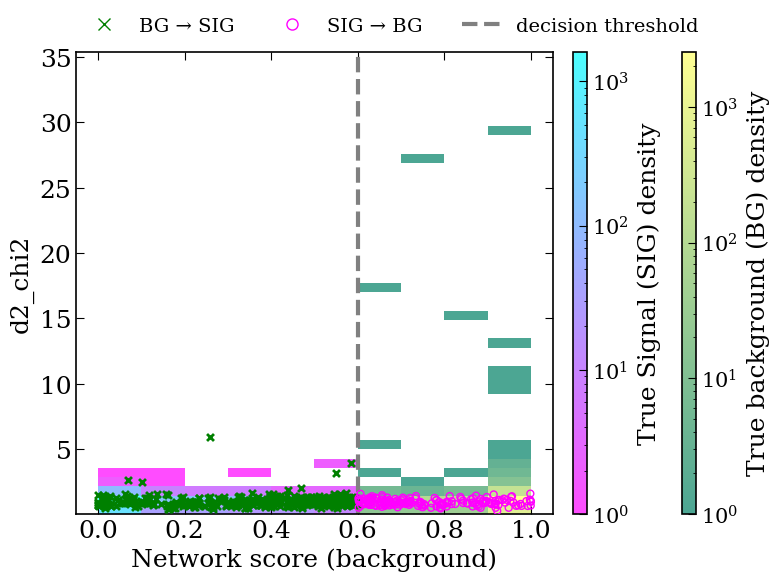

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='d2_chi2'>)

In [62]:
prob_vs_feature(8,thresh=0.6)   

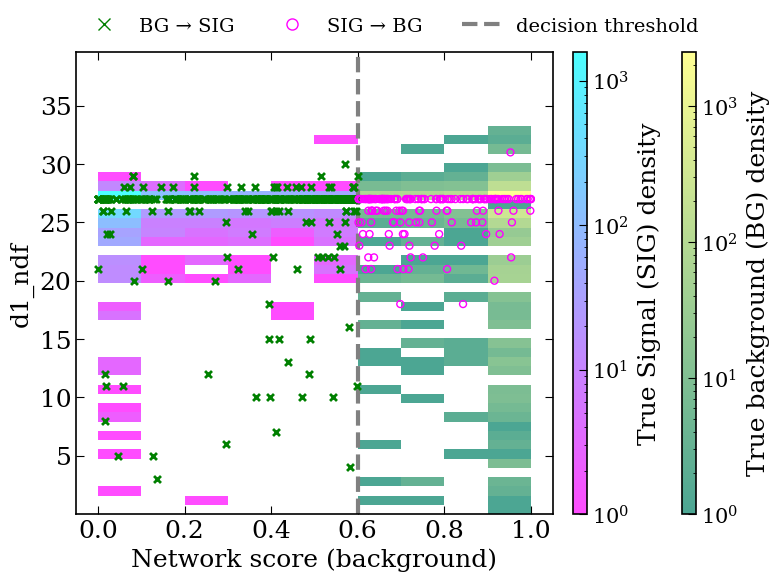

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='d1_ndf'>)

In [63]:
prob_vs_feature(9,thresh=0.6)   

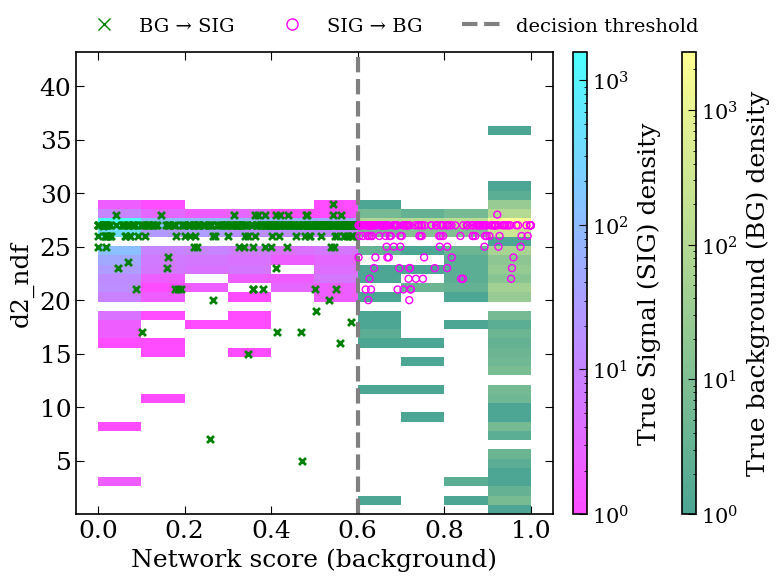

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='d2_ndf'>)

In [64]:
prob_vs_feature(10,thresh=0.6)   

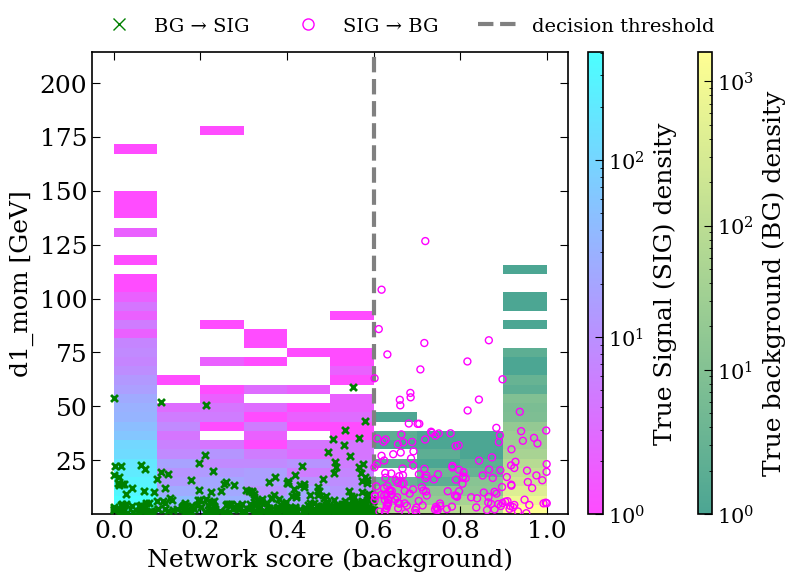

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='d1_mom [GeV]'>)

In [65]:
prob_vs_feature(11,thresh=0.6)   

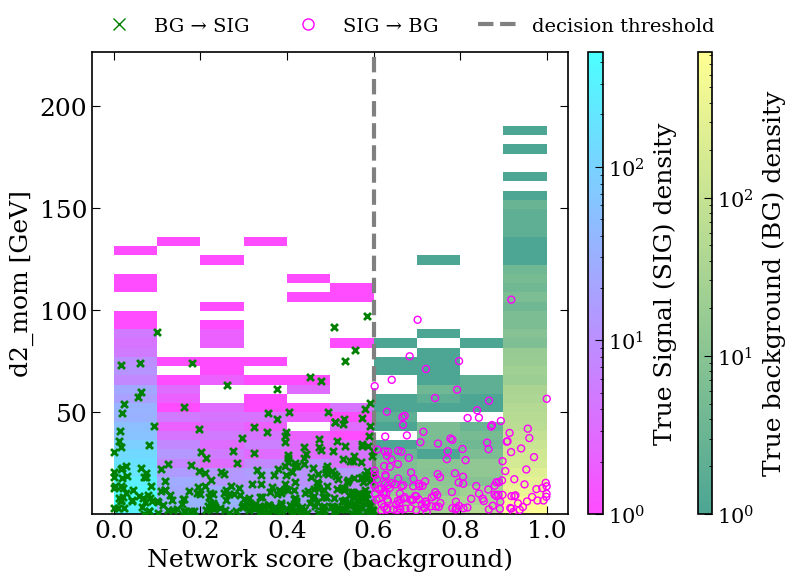

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='d2_mom [GeV]'>)

In [66]:
prob_vs_feature(12,thresh=0.6)   

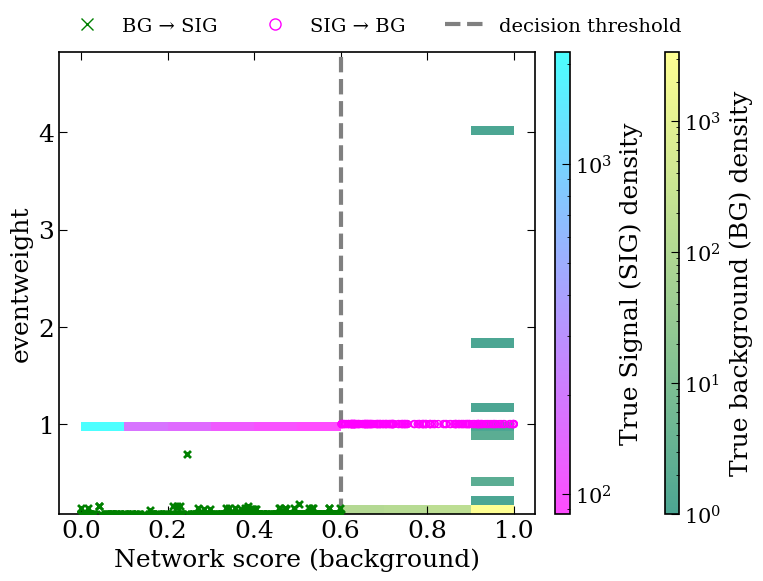

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='eventweight'>)

In [67]:
prob_vs_feature(14,thresh=0.6) 

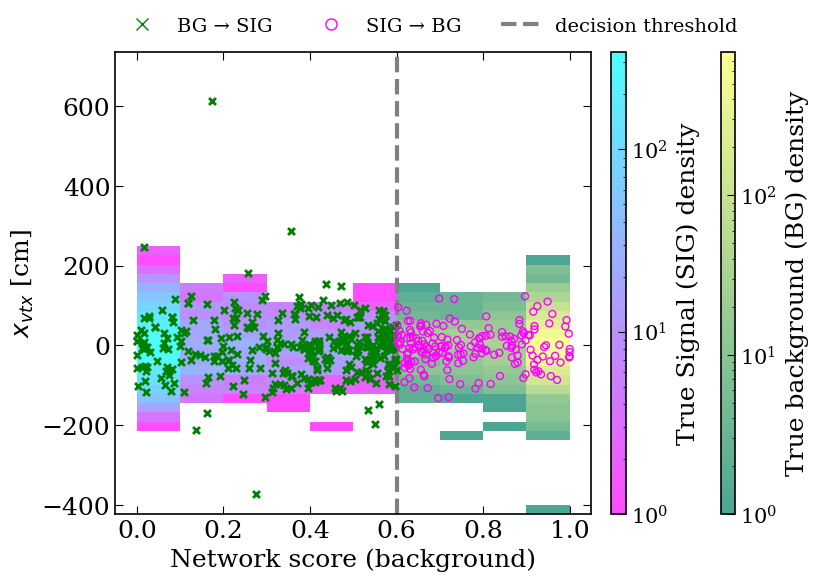

(<Figure size 800x600 with 3 Axes>,
 <Axes: xlabel='Network score (background)', ylabel='$x_{vtx}$ [cm]'>)

In [68]:
prob_vs_feature(0,thresh=0.6)